### LSE Data Analytics Online Career Accelerator 

# DA301:  Advanced Analytics for Organisational Impact

## Assignment template

### Scenario
You are a data analyst working for Turtle Games, a game manufacturer and retailer. They manufacture and sell their own products, along with sourcing and selling products manufactured by other companies. Their product range includes books, board games, video games and toys. They have a global customer base and have a business objective of improving overall sales performance by utilising customer trends. In particular, Turtle Games wants to understand: 
- how customers accumulate loyalty points (Week 1)
- exploring the structure using decision trees (Week 2)
- exploring clusters in customer behaviour (Week 3)
- can social data (e.g. customer reviews) be used in marketing campaigns (Week 4)
- loading, transforming and visualising data in R (Week 5)
- statistical analysis and modelling in R (Week 6)

# Week 1 assignment: Linear regression using Python
The marketing department of Turtle Games prefers Python for data analysis. As you are fluent in Python, they asked you to assist with data analysis of social media data. The marketing department wants to better understand how users accumulate loyalty points. Therefore, you need to investigate the possible relationships between the loyalty points, age, remuneration, and spending scores. Note that you will use this data set in future modules as well and it is, therefore, strongly encouraged to first clean the data as per provided guidelines and then save a copy of the clean data for future use.

## Instructions
1. Load and explore the data.
    1. Create a new DataFrame (e.g. reviews).
    2. Sense-check the DataFrame.
    3. Determine if there are any missing values in the DataFrame.
    4. Create a summary of the descriptive statistics.
2. Remove redundant columns (`language` and `platform`).
3. Change column headings to names that are easier to reference (e.g. `renumeration` and `spending_score`).
4. Save a copy of the clean DataFrame as a CSV file. Import the file to sense-check.
5. Use linear regression and goodness of fit metrics to evaluate possible linear relationships between loyalty points and age/renumeration/spending scores to determine whether these can be used to predict the loyalty points.
    1. Specify the independent and dependent variables.
    2. Create the OLS model.
    3. Extract the estimated parameters, standard errors, and predicted values.
    4. Generate the regression table based on the X coefficient and constant values.
    5. Plot the linear regression and add a regression line.
6. Include your insights and observations.

## 1. Load and explore the data

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 
from statsmodels.formula.api import ols

from sklearn import datasets 
from sklearn import linear_model
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
# Load the CSV file(s) as reviews.
reviews = pd.read_csv('turtle_reviews.csv')

# View the DataFrame.
reviews.head()

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,language,platform,product,review,summary
0,Male,18,12.30,39,210,graduate,EN,Web,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,EN,Web,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,EN,Web,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,EN,Web,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,EN,Web,291,As my review of GF9's previous screens these w...,Money trap


In [3]:
# Any missing values?
reviews.isna().sum()

gender                    0
age                       0
remuneration (k£)         0
spending_score (1-100)    0
loyalty_points            0
education                 0
language                  0
platform                  0
product                   0
review                    0
summary                   0
dtype: int64

There are no missing values within the data.

In [4]:
# Explore the data.
print(reviews.info())
print(reviews.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  2000 non-null   object 
 1   age                     2000 non-null   int64  
 2   remuneration (k£)       2000 non-null   float64
 3   spending_score (1-100)  2000 non-null   int64  
 4   loyalty_points          2000 non-null   int64  
 5   education               2000 non-null   object 
 6   language                2000 non-null   object 
 7   platform                2000 non-null   object 
 8   product                 2000 non-null   int64  
 9   review                  2000 non-null   object 
 10  summary                 2000 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 172.0+ KB
None
Index(['gender', 'age', 'remuneration (k£)', 'spending_score (1-100)',
       'loyalty_points', 'education', 'language', 'platform', 'p

There are 11 columns (variables) and 2000 rows (observations). There are some quantitative variables and some qualitative variables. The column names need tidying up. 

In [5]:
# Basic descriptive statistics.
reviews.describe()

,age,remuneration (k£),spending_score (1-100),loyalty_points,product
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,39.495000,48.079060,50.000000,1578.032000,4320.521500
std,13.573212,23.123984,26.094702,1283.239705,3148.938839
min,17.000000,12.300000,1.000000,25.000000,107.000000
25%,29.000000,30.340000,32.000000,772.000000,1589.250000
50%,38.000000,47.150000,50.000000,1276.000000,3624.000000
75%,49.000000,63.960000,73.000000,1751.250000,6654.000000
max,72.000000,112.340000,99.000000,6847.000000,11086.000000


In [6]:
# View basic descriptive statistics rounded to two decimal places.
reviews.describe().round(2)

,age,remuneration (k£),spending_score (1-100),loyalty_points,product
count,2000.00,2000.00,2000.00,2000.00,2000.00
mean,39.49,48.08,50.00,1578.03,4320.52
std,13.57,23.12,26.09,1283.24,3148.94
min,17.00,12.30,1.00,25.00,107.00
25%,29.00,30.34,32.00,772.00,1589.25
50%,38.00,47.15,50.00,1276.00,3624.00
75%,49.00,63.96,73.00,1751.25,6654.00
max,72.00,112.34,99.00,6847.00,11086.00


These are the descriptive statistics for the numeric variables. The descriptive statistics have been rounded to two decimal places to match the float object in the data set.  The youngest customer is 17, the oldest is 72. The average income is £48080. The highest income is £112340, and the lowest is £12300. Spending score ranges between 1 and 100, with the lowest being 1 and the highest being 99. The descriptive statistics for the product column is pointless. This is because even though the observations in that column are numeric, they represent categoric data as they are a unique code for each product.

## 2. Drop columns

In [7]:
# Drop unnecessary columns.
reviews = reviews.drop(columns=['language', 'platform'])

# View column names.
print(reviews.columns)

# View the newly cleaned DataFrame.
reviews.head()

Index(['gender', 'age', 'remuneration (k£)', 'spending_score (1-100)',
       'loyalty_points', 'education', 'product', 'review', 'summary'],
      dtype='object')


,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


Language and Platform were removed because all the observations were in English, and they were all off the web platform, therefore they were redundant.

## 3. Rename columns

In [8]:
# Rename the column headers.
reviews = reviews.rename(columns={'remuneration (k£)' : 'income',
                                  'spending_score (1-100)' : 'spending_score'})

# View column names.
print(reviews.columns)

# View the newly cleaned DataFrame.
reviews.head()

Index(['gender', 'age', 'income', 'spending_score', 'loyalty_points',
       'education', 'product', 'review', 'summary'],
      dtype='object')


,gender,age,income,spending_score,loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


Columns were renamed to follow standard convention of snake_case. Remuneration was renamed income as per the metadata file.

## 4. Save the DataFrame as a CSV file

In [9]:
# Create a CSV file as output.
reviews.to_csv('turtle_clean.csv', index=False)

In [10]:
# Import new CSV file with Pandas.
turtle = pd.read_csv('turtle_clean.csv')

# View DataFrame.
print(turtle.shape)
print(turtle.info())
turtle.head()

(2000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          2000 non-null   object 
 1   age             2000 non-null   int64  
 2   income          2000 non-null   float64
 3   spending_score  2000 non-null   int64  
 4   loyalty_points  2000 non-null   int64  
 5   education       2000 non-null   object 
 6   product         2000 non-null   int64  
 7   review          2000 non-null   object 
 8   summary         2000 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 140.8+ KB
None


,gender,age,income,spending_score,loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


Cleaned CSV read successfully.


## 5. Linear regression

### 5a) spending vs loyalty

In [11]:
# Define independent variable.
x = turtle['spending_score'].values.reshape(-1,1)

# Define dependent variable.
y = turtle['loyalty_points'].values.reshape(-1,1)

# Create model and print summary of metrics.
lr = linear_model.LinearRegression()
lr.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
# Extract the estimated parameters.
print("Intercept:", lr.intercept_)
print("Coefficients:", lr.coef_[0])

# Extract the predicted values.
y_pred = lr.predict(x)
y_pred

Intercept: [-75.05266293]
Coefficients: [33.06169326]


array([[1214.35337415],
       [2602.94449102],
       [ 123.31749662],
       ...,
       [2933.56142361],
       [ 453.93442921],
       [ 189.44088314]], shape=(2000, 1))

In [13]:
# Create an OLS model.
f = 'y ~ x'
test = ols(f, data=turtle).fit()

# Print the regression table.
test.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     1648.
Date:                Mon, 20 Jul 2026   Prob (F-statistic):          2.92e-263
Time:                        10:57:38   Log-Likelihood:                -16550.
No. Observations:                2000   AIC:                         3.310e+04
Df Residuals:                    1998   BIC:                         3.312e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -75.0527     45.931     -1.634      0.102    -165.129      15.024
x             33.0617      0.814     40.595      0.000      31.464      34.659
==============================================================================
Omnibus:                      126.554   Durbin-Watson:                   1.191
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              260.528
Skew:                           0.422   Prob(JB):                     2.67e-57
Kurtosis:                       4.554   Cond. No.                         122.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [14]:
# Extract the estimated parameters.
print(f"""
Estimated Parameters:
Intercept: {test.params['Intercept']}
x coefficent: {test.params['x']}
""")

# Extract the standard errors.
print(f"""
Standard Errors:
Intercept: {test.bse['Intercept']}
x: {test.bse['x']}
""")

# Extract the predicted values.
print(f"""
predicted Values: {test.fittedvalues}
""")


Estimated Parameters:
Intercept: -75.05266293364745
x coefficent: 33.06169325867301


Standard Errors:
Intercept: 45.93055405556938
x: 0.8144185085135343


predicted Values: 0       1214.353374
1       2602.944491
2        123.317497
3       2470.697718
4       1247.415067
           ...     
1995    2206.204172
1996     189.440883
1997    2933.561424
1998     453.934429
1999     189.440883
Length: 2000, dtype: float64



This gives an R2 value of 0.452 (45.2%) which shows a moderate relationship between spending score and loyalty points. However,the t value is 40.595, which is high, alongside a P value of 0.102, showing a high statistical significance. The x coefficient is 33.0617 - this means for every single increase of the spending score, the loyaylty points increase by approximately 33.

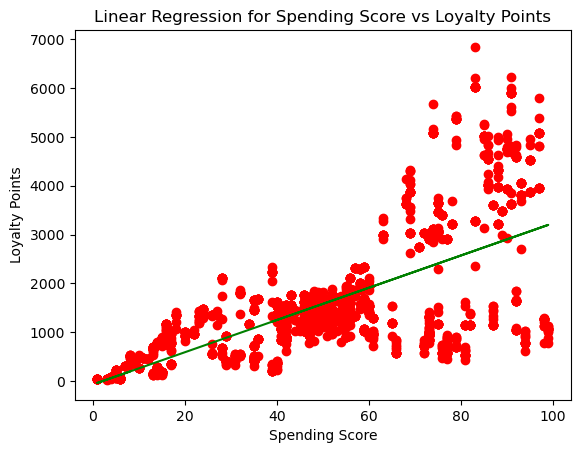

In [15]:
# Plot the graph with a regression line.
plt.scatter(x, y, color = 'red')
plt.plot(x, y_pred, color = 'green')
plt.title("Linear Regression for Spending Score vs Loyalty Points")
plt.xlabel("Spending Score")
plt.ylabel("Loyalty Points");

This shows a positive linear relationship, especially for spending scores below 60. As the spending score gets above 60, the loyalty points become more spread out.

### 5b) income vs loyalty

In [16]:
# Define independent variable.
x = turtle['income'].values.reshape(-1,1)

# Define dependent variable.
y = turtle['loyalty_points'].values.reshape(-1,1)

# Create model and print summary of metrics.
f = 'y ~ x'
test = ols(f, data = turtle).fit()

# View test summary.
test.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     1222.
Date:                Mon, 20 Jul 2026   Prob (F-statistic):          2.43e-209
Time:                        10:57:39   Log-Likelihood:                -16674.
No. Observations:                2000   AIC:                         3.335e+04
Df Residuals:                    1998   BIC:                         3.336e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -65.6865     52.171     -1.259      0.208    -168.001      36.628
x             34.1878      0.978     34.960      0.000      32.270      36.106
==============================================================================
Omnibus:                       21.285   Durbin-Watson:                   3.622
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               31.715
Skew:                           0.089   Prob(JB):                     1.30e-07
Kurtosis:                       3.590   Cond. No.                         123.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [17]:
# Extract the estimated parameters.
print(f"""
Estimated Parameters:
Intercept: {test.params['Intercept']}
x coefficent: {test.params['x']}
""")

# Extract the standard errors.
print(f"""
Standard Errors:
Intercept: {test.bse['Intercept']}
x: {test.bse['x']}
""")



Estimated Parameters:
Intercept: -65.68651279500628
x coefficent: 34.1878254856689


Standard Errors:
Intercept: 52.17071742983615
x: 0.9779254568320984



This shows an R2 value of 0.380 (38%). This means that income has a weaker relationship to loyalty points compared to spending score. The t value is 34.960 and the correspoding P value is 0.208, which suggest that income has less of a statistical significance with loyalty points compared to spending score. The coefficient is 34.1878, this means as the income goes up by one, the loyalty points will go up by approximately 34.

In [18]:
# Create a prediction object.
y_pred = test.fittedvalues

# View predictions.
y_pred

0        354.823741
1        354.823741
2        382.857758
3        382.857758
4        410.891774
           ...     
1995    2821.817228
1996    3102.157397
1997    3102.157397
1998    3298.395515
1999    3102.157397
Length: 2000, dtype: float64

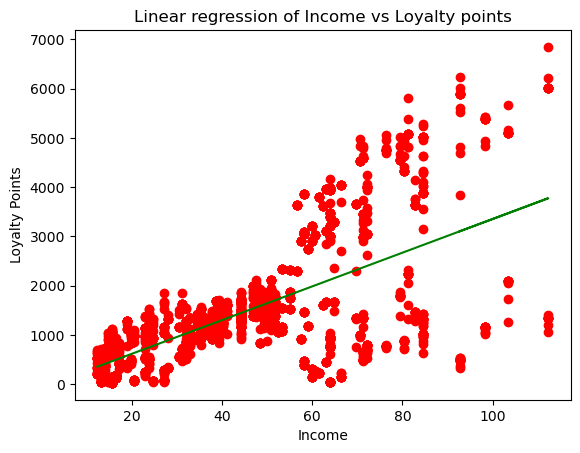

In [19]:
# Plot graph with regression line.
plt.scatter(x, y, color = 'red')
plt.plot(x, y_pred, color = 'green')
plt.title("Linear regression of Income vs Loyalty points")
plt.xlabel("Income")
plt.ylabel("Loyalty Points");

This shows another positive relationship between income and loyalty points. As income goes up, loyalty points go up. An income of around £50000 would be have an effect on loyalty points, however, above £50000 the points become wider spread and making income a weaker predictor of loyalty points.

### 5c) age vs loyalty

In [20]:
# Define independent variable.
x = turtle['age'].values.reshape(-1,1)

# Define dependent variable.
y = turtle['loyalty_points'].values.reshape(-1,1)

# Create model and print summary of metrics.
f = 'y ~ x'
test = ols(f, data=turtle).fit()

# View the test summary.
test.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.606
Date:                Mon, 20 Jul 2026   Prob (F-statistic):             0.0577
Time:                        10:57:39   Log-Likelihood:                -17150.
No. Observations:                2000   AIC:                         3.430e+04
Df Residuals:                    1998   BIC:                         3.431e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1736.5177     88.249     19.678      0.000    1563.449    1909.587
x             -4.0128      2.113     -1.899      0.058      -8.157       0.131
==============================================================================
Omnibus:                      481.477   Durbin-Watson:                   2.277
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              937.734
Skew:                           1.449   Prob(JB):                    2.36e-204
Kurtosis:                       4.688   Cond. No.                         129.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [21]:
# Extract the estimated parameters.
print(f"""
Estimated Parameters:
Intercept: {test.params['Intercept']}
x: {test.params['x']}
""")

# Extract the standard errors.
print(f"""
Standard Errors:
Intercept: {test.bse['Intercept']}
x: {test.bse['x']}
""")



Estimated Parameters:
Intercept: 1736.5177393990632
x: -4.012805149995205


Standard Errors:
Intercept: 88.24873115454396
x: 2.1131768876430828



The R2 value is 0.002 (0.2%), this means that the relationship between age in loyalty points is weak. The absolute t-value is 1.899 with a P-value of 0.058, which suggests that the there is little statistical significance between age and loyalty points. The coefficient is -4.0128 which suggests that the older the customer is, the loyalty points will go down by approximately 4.

In [22]:
# Create an object for the predicted values.
y_pred = test.fittedvalues

# View the predicted values.
y_pred

0       1664.287247
1       1644.223221
2       1648.236026
3       1636.197611
4       1604.095169
           ...     
1995    1588.043949
1996    1563.967118
1997    1600.082364
1998    1600.082364
1999    1608.107975
Length: 2000, dtype: float64

Text(0, 0.5, 'Loyalty Points')

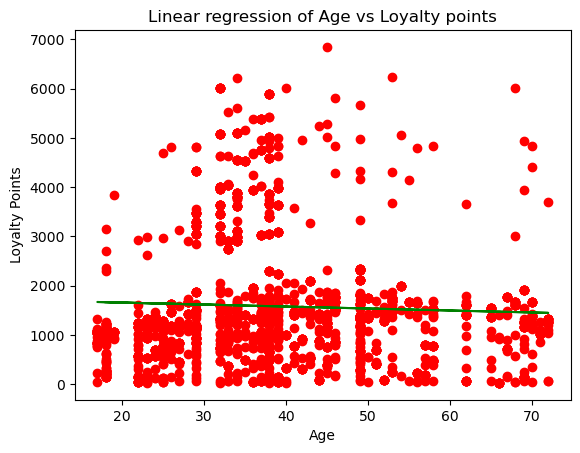

In [23]:
# Plot graph with regression line.
plt.scatter(x, y, color = 'red')
plt.plot(x, y_pred, color = 'green')
plt.title("Linear regression of Age vs Loyalty points")
plt.xlabel("Age")
plt.ylabel("Loyalty Points")

This plot shows that the relationship between age and loyalty points is not a significant indicator of loyalty points accumulation. There is a slight negative correlation but that is not significant. The data points do not follow the regression line.

## 6. Observations and insights

***Your observations here...***






Spending score has the greatest impact towards loyalty points, followed closely by income. The age of a customer does not have an impact on the loyalty points. For future investigations; creating a multiple linear regression of spending score and income against loyaylty points would be advisable, with age being omitted.

# Week 2 assignment: Exploring the structure using decision trees.

The team wants you to use decision trees to attempt to better understand the structure found in the data. You need to grow and prune a decision tree regressor and then visualise and interpret the output.
Make sure to comment on the potential usefulness in decision-making processes and your observations regarding the model.

## Instructions
1. Prepare the data for creating your decision tree. 
    1. Import the CSV file you have prepared in Week 1.
    2. Create a new DataFrame with the appropriate columns.
        1. Specify that loyalty points is the target variable (Y) and should be excluded from your input data.
        2. Specify X for the independent variables and y as the dependent variable. Therefore, df\[cols\] will be the independent variables and the column containing loyalty points the dependent variable.
        3. Explore the new DataFrame. 
2. Split the data set into a train and test sets for both X and y at a 70:30 ratio. As previously, random_state=42.
3. Create a decision tree regressor to explore the impact of other features on the loyalty points.
    1. Import the DecisionTreeRegressor class from the sklearn.tree library. 
    2. Create a variable (e.g. regressor) to store the DecisionTreeRegressor() class. (As previously, random_state=42.).
    3. Fit the regressor object to the data set with the fit() function.
    4. Remember to prune your tree using basic pruning strategies and compare the performance before and after applying the pruning strategy.
    5. Plot the final decision tree.
4. Fit a final model and interpret the output.
    1. Justify your selection of pruning strategy implemented and interpret the output.
    2. Evaluate the usefulness of the obtained result and interpret the tree and how it could be used to inform business decisions in the organisation.
5. Summarise (150–200 words) the most important business insights, anything you would like to explore further, and suggested future actions.
 
Back up your work to a safe location. This will allow you to revert to a previous state in the case of making a mistake in the code or deleting a section by mistake. (A simple way of doing this is to save or email a compressed version to yourself at frequent intervals.)


## 1. Load and prepare the data

In [24]:
# Import all the necessary packages
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree 
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import warnings
import matplotlib.pyplot as plt
import math

# Settings for the notebook.
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = [15, 10]

In [25]:
# Create your new DataFrame.
turtle2 = pd.read_csv('turtle_clean.csv')

# View the new DataFrame.
turtle2.head()

,gender,age,income,spending_score,loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


In [26]:
# Specify Y.
y = turtle2['loyalty_points']
# Specify X.
# Select the necessary columns for X.
cols = ['gender',
        'age',
        'spending_score',
        'income', 
        'education']
X = turtle[cols]

In [27]:
# Review X and Y.
print(y.head())
X.head()

0    210
1    524
2     40
3    562
4    366
Name: loyalty_points, dtype: int64


,gender,age,spending_score,income,education
0,Male,18,39,12.30,graduate
1,Male,23,81,12.30,graduate
2,Female,22,6,13.12,graduate
3,Female,25,77,13.12,graduate
4,Female,33,40,13.94,graduate


Product was ignore because it is a categoric variable even though it is numeric. Gender and education will be made it to dummy variables to create numeric variables.

In [28]:
# Create dummy variables due to some columns not being numeric.
X = pd.get_dummies(X, drop_first=True,
                  dtype=int)

# View new dummied X DataFrame.
print(X.dtypes)
X.head()

age                         int64
spending_score              int64
income                    float64
gender_Male                 int64
education_PhD               int64
education_diploma           int64
education_graduate          int64
education_postgraduate      int64
dtype: object


,age,spending_score,income,gender_Male,education_PhD,education_diploma,education_graduate,education_postgraduate
0,18,39,12.30,1,0,0,1,0
1,23,81,12.30,1,0,0,1,0
2,22,6,13.12,0,0,0,1,0
3,25,77,13.12,0,0,0,1,0
4,33,40,13.94,0,0,0,1,0


## 2. Create train and test data sets.

In [29]:
# Split the data into test and train data.
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, 
                                                    test_size = 0.30)

## 3. Create Decision tree regressor

In [30]:
# Create your decision tree regressor.
# Create your decision tree regressor.
# Import the 'DecisionTreeRegressor' class from sklearn
from sklearn.tree import DecisionTreeRegressor

# Create the 'DecisionTreeRegressor' class.
regressor = DecisionTreeRegressor(random_state=42)

# Fit the regressor object to the data set.
regressor.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


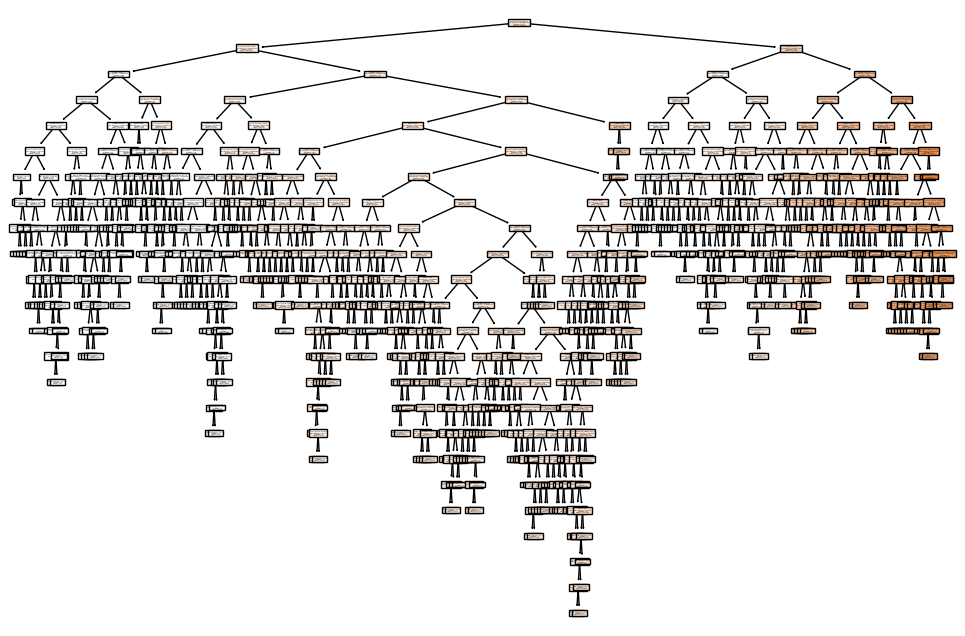

In [31]:
# Plot the tree
plt.figure(figsize=(12,8))

plot_tree(regressor,
          feature_names=X.columns,
          filled=True)

plt.show()

This shows lots of branches. It might suggest that the decision tree is picking up noise and becoming over-fitted. Pruning is advised.

In [32]:
# Evaluate the model.
# Predict the response for the data test.
y_predict = regressor.predict(X_test)

# Specify to print the MAE and MSE (to evaluate the accuracy of the new model).
print("Mean Absolute Error: ", metrics.mean_absolute_error(y_test, y_predict))
print("Mean Squared Error: ", metrics.mean_squared_error(y_test, y_predict))
# Calculate the RMSE.
print("Root Mean Squared Error: ", math.sqrt(metrics.mean_squared_error(y_test, y_predict)))

Mean Absolute Error:  32.513333333333335
Mean Squared Error:  8072.756666666667
Root Mean Squared Error:  89.84852067044102


In [33]:
# Round the errors.
print("Mean Absolute Error: ", round(metrics.mean_absolute_error(y_test, y_predict), 2))
print("Mean Squared Error: ", round(metrics.mean_squared_error(y_test, y_predict),2))
# Calculate the RMSE.
print("Root Mean Squared Error: ", round(math.sqrt(metrics.mean_squared_error(y_test, y_predict)),2))

Mean Absolute Error:  32.51
Mean Squared Error:  8072.76
Root Mean Squared Error:  89.85


The MAE shows that the average error (distance between actal value and predicted value) is 39.25.
The MSE and RMSE are 10197.56 and 100.98 respectively.
The RMSE is significantly higher than the MAE, and therefore the model makes some large errors. Even though the are some large errors, the model is reasonbly accurate.

In [34]:
# Prune the model.
# Determine the optimal value for max depth
# List of values to try for max_depth:
max_depth_range = list(range(1, 7))
# List to store the accuracy for each value of max_depth:
accuracy = []
for depth in max_depth_range:
    
    regressor2 = DecisionTreeRegressor(max_depth = depth, random_state = 42)
    regressor2.fit(X_train, y_train)
    score = regressor2.score(X_test, y_test)
    accuracy.append(score)

<Axes: >

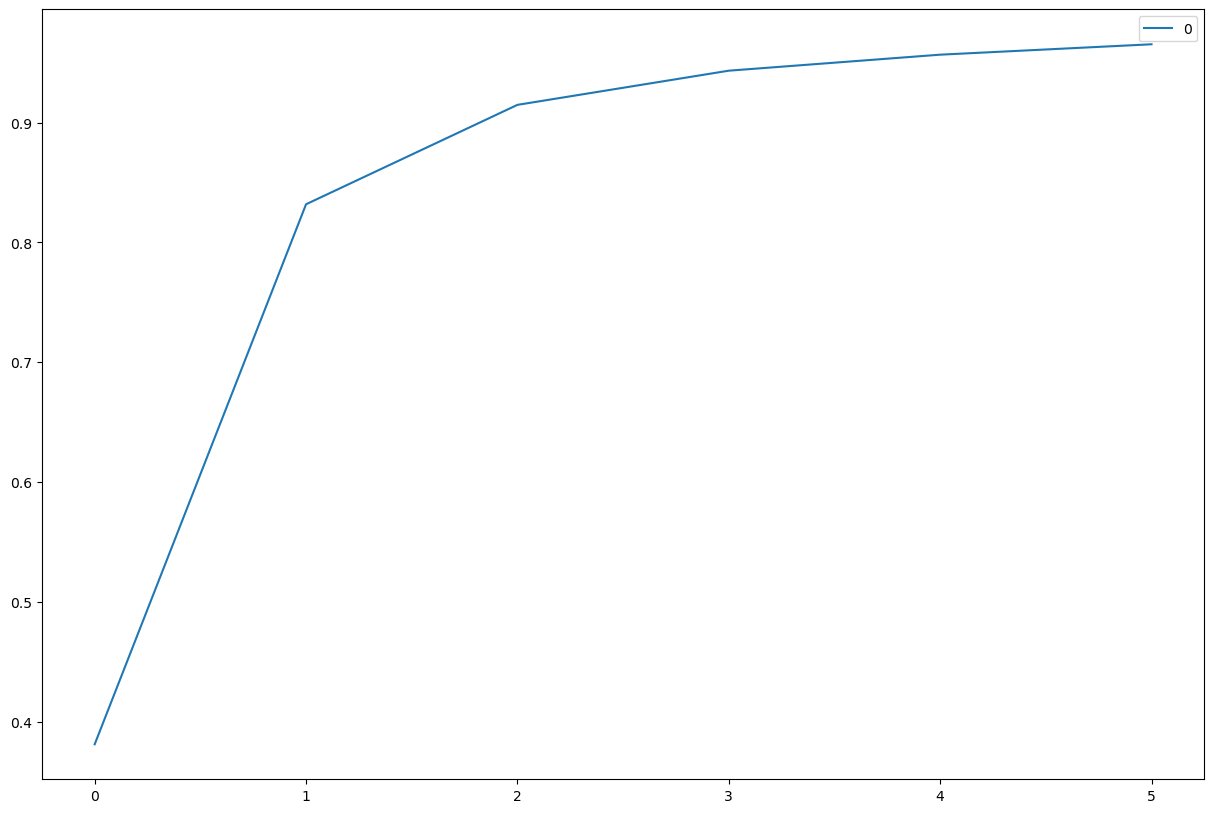

In [35]:
# Plot accuracy values across the range of depth values evaluated
accuracy = pd.DataFrame(accuracy)
accuracy.plot()

The accuracy tails off after 2 branches, so best to aim for a max depth of 2

In [36]:
# Prune the tree
regressor_pruned = DecisionTreeRegressor(max_depth=2,
                                         random_state=42)

# Fit the pruned tree.
regressor_pruned.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


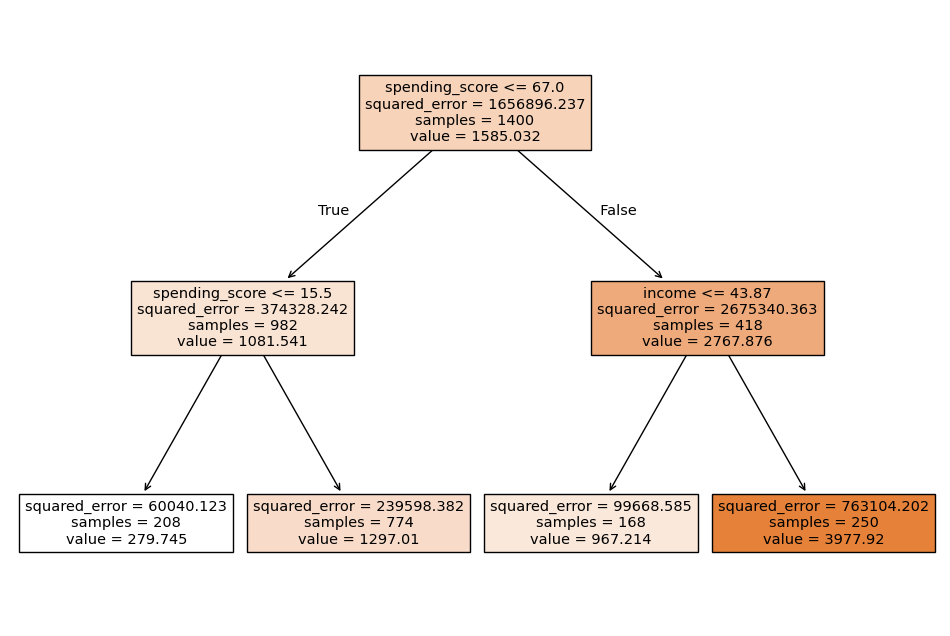

In [37]:
# Plot pruned tree.
plt.figure(figsize=(12,8))

plot_tree(regressor_pruned,
          feature_names=X.columns,
          filled=True)

plt.show()

Spending score greater than or equal to 

In [38]:
# Evaluate the pruned tree.
# Evaluate the model.
# Predict the response for the data test.
y_predict_pruned = regressor.predict(X_test)

# Specify to print the MAE and MSE (to evaluate the accuracy of the new model).
print("Mean Absolute Error: ", metrics.mean_absolute_error(y_test, y_predict_pruned))
print("Mean Squared Error: ", metrics.mean_squared_error(y_test, y_predict_pruned))
# Calculate the RMSE.
print("Root Mean Squared Error: ", math.sqrt(metrics.mean_squared_error(y_test, y_predict_pruned)))

Mean Absolute Error:  32.513333333333335
Mean Squared Error:  8072.756666666667
Root Mean Squared Error:  89.84852067044102


In [39]:
# Round the pruned tree errors.
print("Mean Absolute Error: ", round(metrics.mean_absolute_error(y_test, y_predict_pruned), 2))
print("Mean Squared Error: ", round(metrics.mean_squared_error(y_test, y_predict_pruned),2))
# Calculate the RMSE.
print("Root Mean Squared Error: ", round(math.sqrt(metrics.mean_squared_error(y_test, y_predict_pruned)),2))

Mean Absolute Error:  32.51
Mean Squared Error:  8072.76
Root Mean Squared Error:  89.85


The errors are the same with the originial tree and the pruned tree. The model should be used at depth 2 for a simpler model.

## 4. Fit and plot final model.

In [40]:
# Fit and plot final model.
final_model = DecisionTreeRegressor(random_state=42,
                                    max_depth=2)
final_model.fit(X, y)
print("Tree depth =", final_model.get_depth(), '\n'
      "Numer of leaves =", final_model.get_n_leaves())

Tree depth = 2 
Numer of leaves = 4


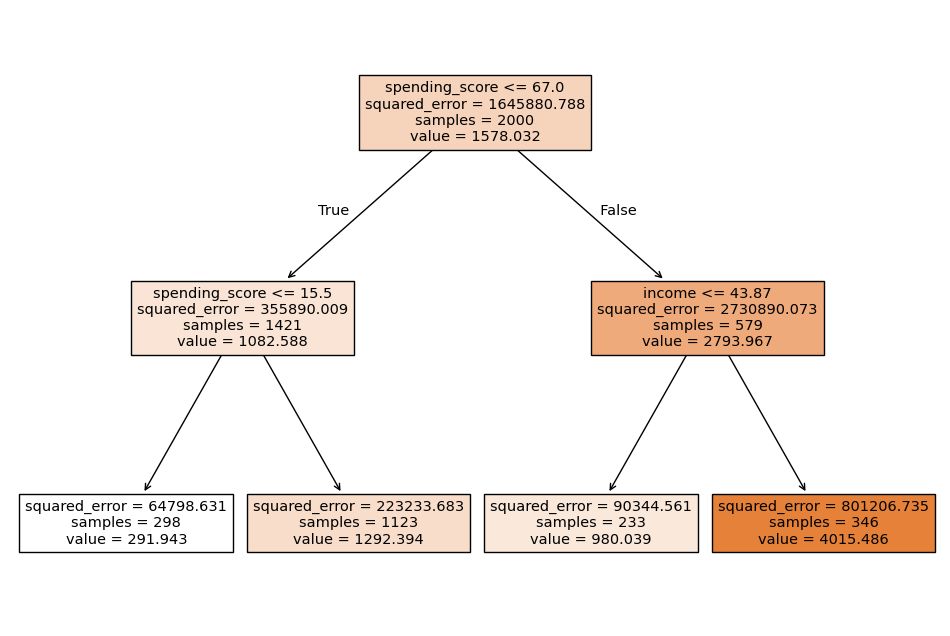

In [41]:
# Plot the final model.
plt.figure(figsize=(12,8))

plot_tree(final_model,
          feature_names=X.columns,
          filled=True)

plt.show()

Spending score is the most important factor for customers accumulating loyalty points. Customers with a spending score less than or equal to 67 have lower loyalty points. It also shows that customers with an income more than £43670 have higher loyalty points.

## 5. Discuss: Insights and observations

***Your observations here...***

Spending score is the most important factor for loyalty points. Customers with a spending score less than or equal to 67 have lower loyalty points. Customers with an income more than £43670 have higher loyalty points when they achieve a spending score above 67. Other variables were not selected in the tree, which suggests that they have little to no contribuition to the final prediction.

# 

# Week 3 assignment: Clustering with *k*-means using Python

The marketing department also wants to better understand the usefulness of renumeration and spending scores but do not know where to begin. You are tasked to identify groups within the customer base that can be used to target specific market segments. Use *k*-means clustering to identify the optimal number of clusters and then apply and plot the data using the created segments.

## Instructions
1. Prepare the data for clustering. 
    1. Import the CSV file you have prepared in Week 1.
    2. Create a new DataFrame (e.g. `df3`) containing the `renumeration` and `spending_score` columns.
    3. Explore the new DataFrame. 
2. Plot the renumeration versus spending score.
    1. Create a scatterplot.
    2. Create a pairplot.
3. Use the Silhouette and Elbow methods to determine the optimal number of clusters for *k*-means clustering.
    1. Plot both methods and explain how you determine the number of clusters to use.
    2. Add titles and legends to the plot.
4. Evaluate the usefulness of at least three values for *k* based on insights from the Elbow and Silhoutte methods.
    1. Plot the predicted *k*-means.
    2. Explain which value might give you the best clustering.
5. Fit a final model using your selected value for *k*.
    1. Justify your selection and comment on the respective cluster sizes of your final solution.
    2. Check the number of observations per predicted class.
6. Plot the clusters and interpret the model.

## 1. Load and explore the data

In [42]:
# Import necessary libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist

import warnings
warnings.filterwarnings('ignore')

In [43]:
# Load the CSV file(s)
turtle3 = pd.read_csv('turtle_clean.csv')

# View DataFrame.
print(turtle3.info())
print(turtle3.columns)
turtle3.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          2000 non-null   object 
 1   age             2000 non-null   int64  
 2   income          2000 non-null   float64
 3   spending_score  2000 non-null   int64  
 4   loyalty_points  2000 non-null   int64  
 5   education       2000 non-null   object 
 6   product         2000 non-null   int64  
 7   review          2000 non-null   object 
 8   summary         2000 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 140.8+ KB
None
Index(['gender', 'age', 'income', 'spending_score', 'loyalty_points',
       'education', 'product', 'review', 'summary'],
      dtype='object')


,gender,age,income,spending_score,loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


In [44]:
# Drop unnecessary columns.
turtle3.drop(columns = ['gender', 'age', 'education',
                       'product', 'review', 'summary'], inplace = True)

# View DataFrame.
turtle3.head()

,income,spending_score,loyalty_points
0,12.30,39,210
1,12.30,81,524
2,13.12,6,40
3,13.12,77,562
4,13.94,40,366


In [45]:
# Explore the data.
turtle3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   income          2000 non-null   float64
 1   spending_score  2000 non-null   int64  
 2   loyalty_points  2000 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 47.0 KB


In [46]:
# Descriptive statistics.
turtle3.describe()

,income,spending_score,loyalty_points
count,2000.000000,2000.000000,2000.000000
mean,48.079060,50.000000,1578.032000
std,23.123984,26.094702,1283.239705
min,12.300000,1.000000,25.000000
25%,30.340000,32.000000,772.000000
50%,47.150000,50.000000,1276.000000
75%,63.960000,73.000000,1751.250000
max,112.340000,99.000000,6847.000000


## 2. Plot

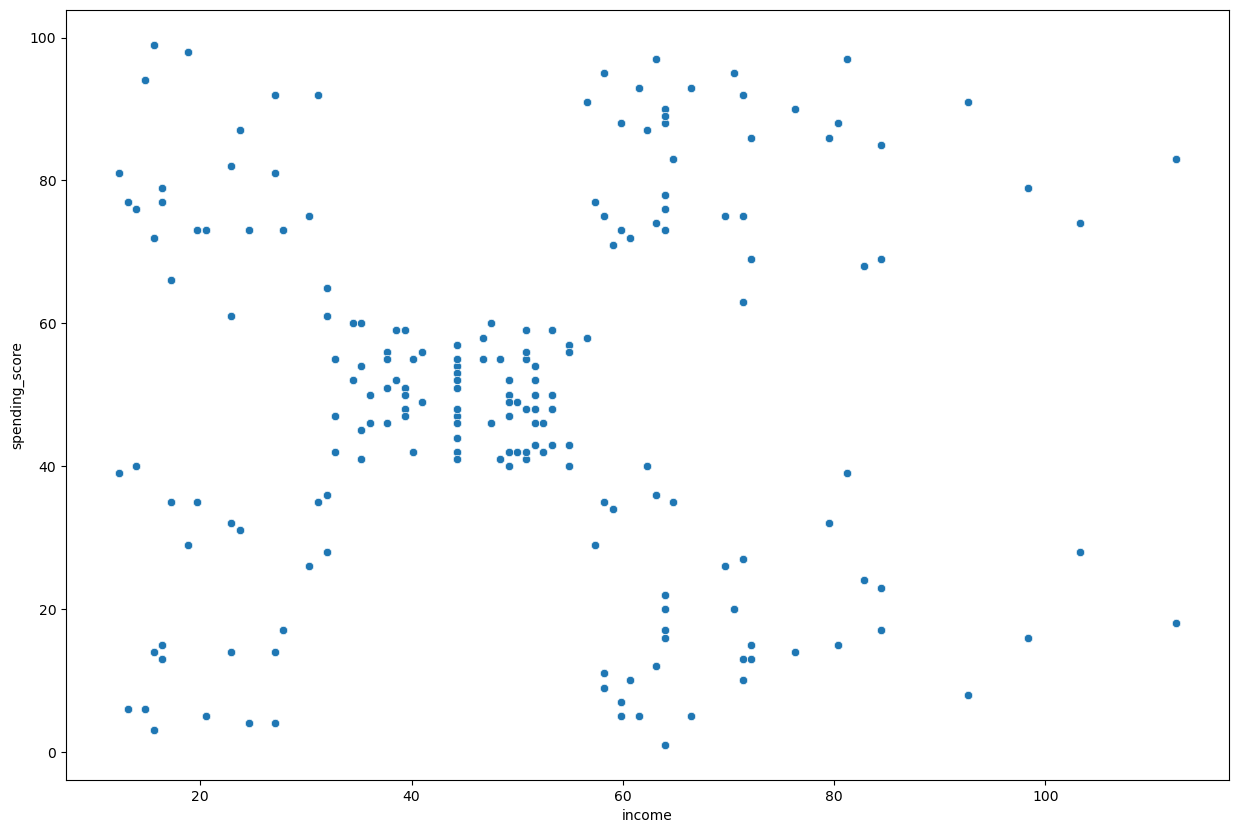

In [47]:
# Create a scatterplot with Seaborn.
sns.scatterplot(x='income',
                y='spending_score',
                data=turtle3);

This shows 5 possible groups.

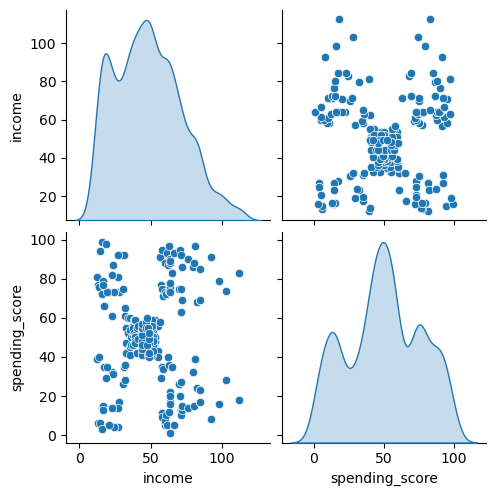

In [48]:
# Create a pairplot with Seaborn.
x = turtle3[['income', 'spending_score']]

sns.pairplot(data=turtle3,
             vars=x,
             diag_kind='kde');

The density plots show that there are multiple groups occuring due to the multiple peaks.

## 3. Elbow and silhoutte methods

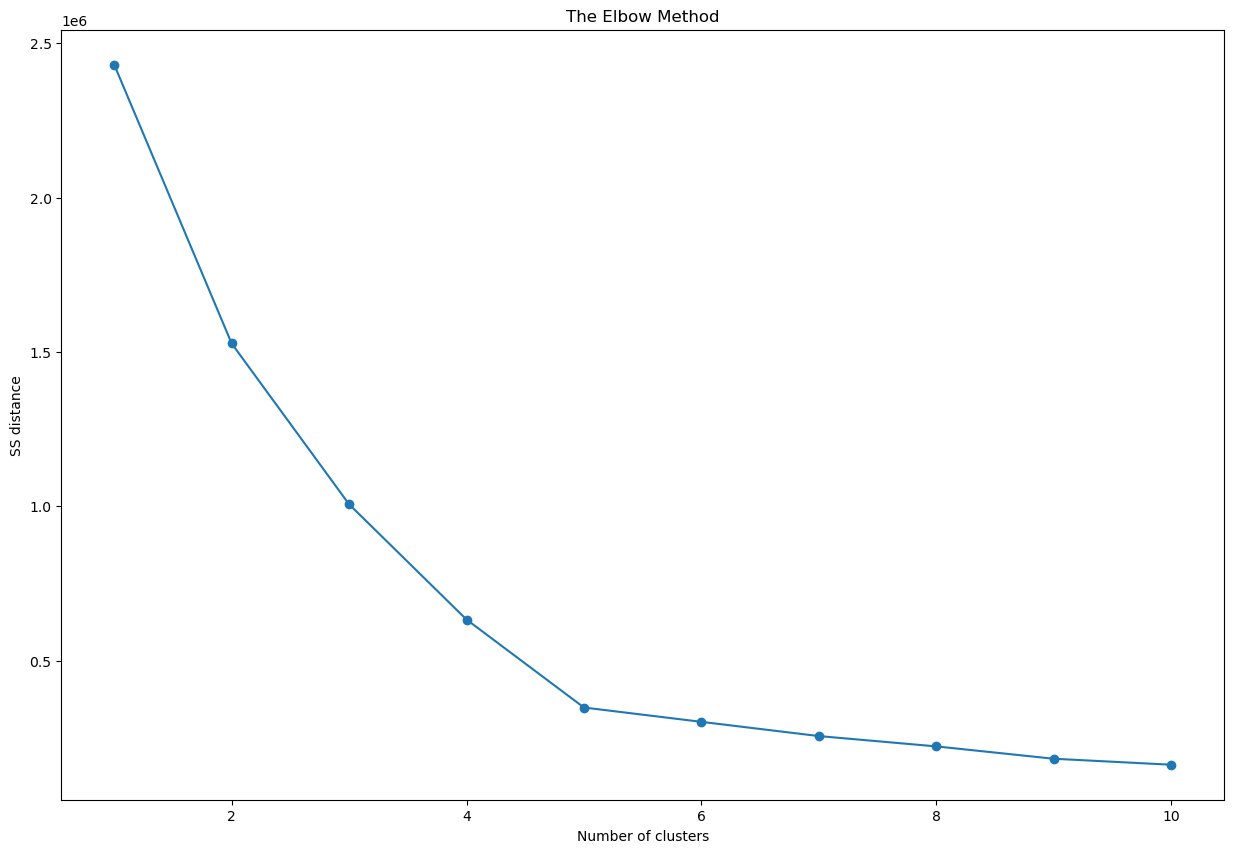

In [49]:
# Determine the number of clusters: Elbow method.
# Elbow chart for us to decide on the numbner of optimal clusters.
ss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,
                    init='k-means++',
                    max_iter=300,
                    n_init=10,
                    random_state=0)
    kmeans.fit(x)
    ss.append(kmeans.inertia_)

# Plot the elbow method.
plt.plot(range(1,11),
         ss,
         marker='o')

# Insert labels and title.
plt.title("The Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("SS distance")

plt.show()

Explore clusters between 3 and 5.

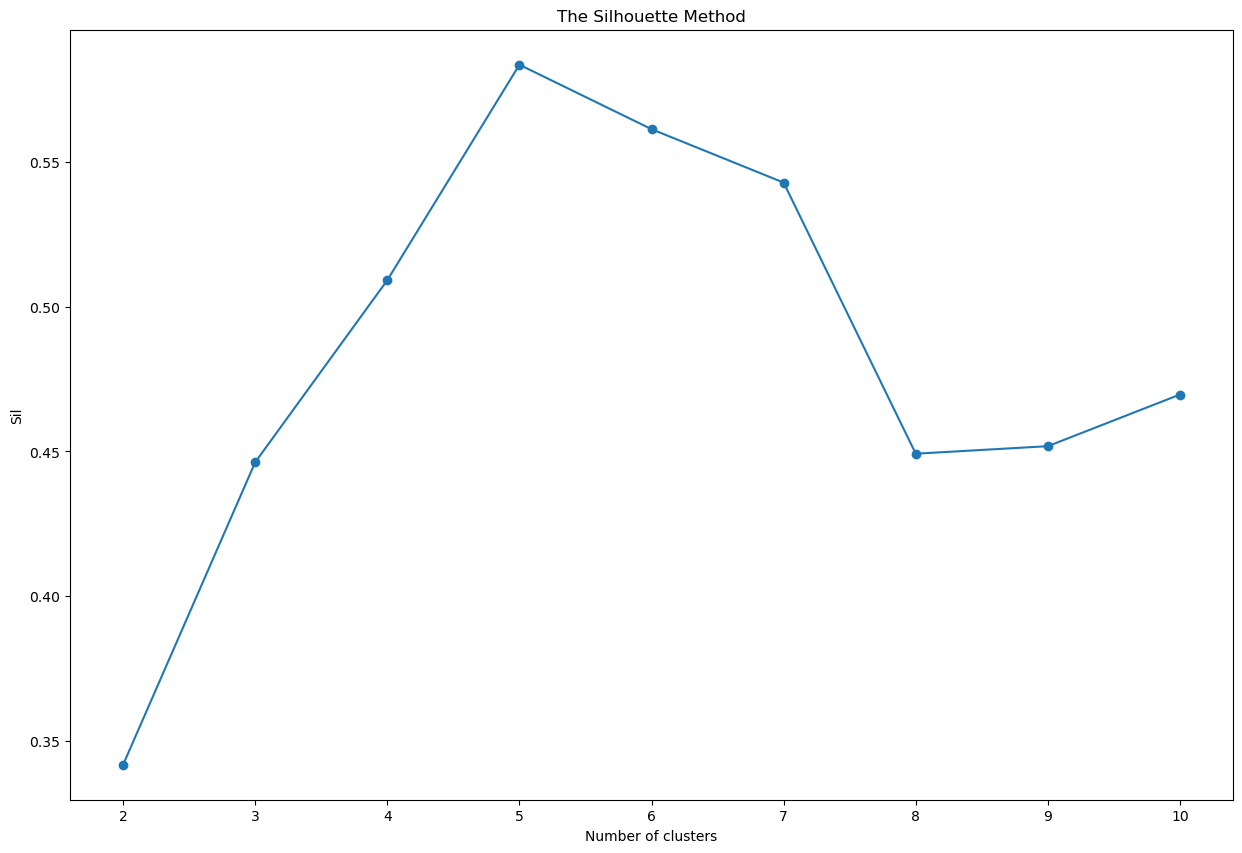

In [50]:
# Determine the number of clusters: Silhouette method.
# Find the range of clusters to be used using silhouette method.
sil = []
kmax = 10

for k in range(2, kmax+1):
    kmeans_s = KMeans(n_clusters=k, random_state=0).fit(x)
    labels = kmeans_s.labels_
    sil.append(silhouette_score(x, 
                                labels,
                                metric='euclidean'))

# Plot the silhouette method.
plt.plot(range(2, kmax+1),
         sil,
         marker='o')

# Insert labels and title.
plt.title("The Silhouette Method")
plt.xlabel("Number of clusters")
plt.ylabel("Sil")

plt.show()

This shows a high sil score at 5. So I'm going to continue with 3,4 and 5 when comparing it with the elbow.

## 4. Evaluate k-means model at different values of *k*

K-Means Predicted
0    1114
1     530
2     356
Name: count, dtype: int64

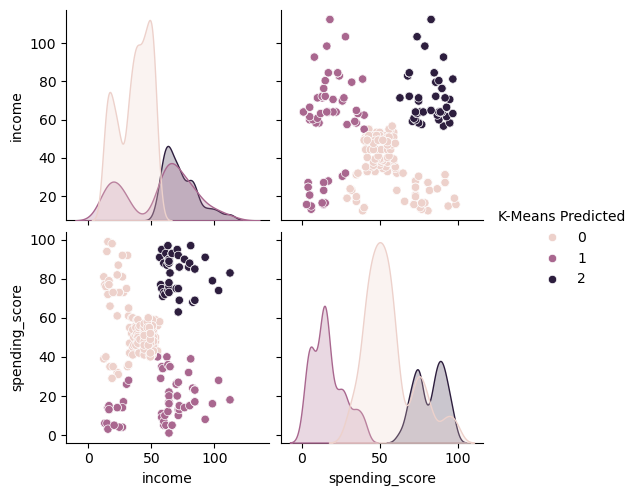

In [51]:
# Using k=3.
kmeans = KMeans(n_clusters = 3,
                max_iter = 15000,
                init = 'k-means++',
                random_state=0).fit(x)

clusters = kmeans.labels_

x['K-Means Predicted'] = clusters

# Plot the predicted. 
sns.pairplot(x,
             hue='K-Means Predicted',
             diag_kind='kde')

# Check the number of observations per predicted class.
x['K-Means Predicted'].value_counts()

This doesn't show that 3 is enough. Looking at the top left chart, K0 and K1 have two peaks. There are a lot more in cluster 0 as well.


K-Means Predicted
0    877
1    498
2    356
3    269
Name: count, dtype: int64

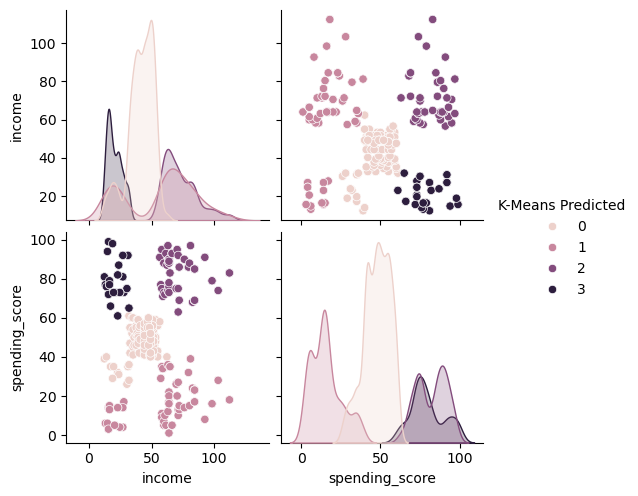

In [52]:
# Using k=4.
kmeans = KMeans(n_clusters = 4,
                max_iter = 15000,
                init = 'k-means++',
                random_state=0).fit(x)

clusters = kmeans.labels_

x['K-Means Predicted'] = clusters

# Plot the predicted. 
sns.pairplot(x,
             hue='K-Means Predicted',
             diag_kind='kde')

# Check the number of observations per predicted class.
x['K-Means Predicted'].value_counts()

There is still two peaks in some of the clusters across the diagonals. There are a lot more in cluster 0 as well.

K-Means Predicted
0    774
2    356
1    330
4    271
3    269
Name: count, dtype: int64

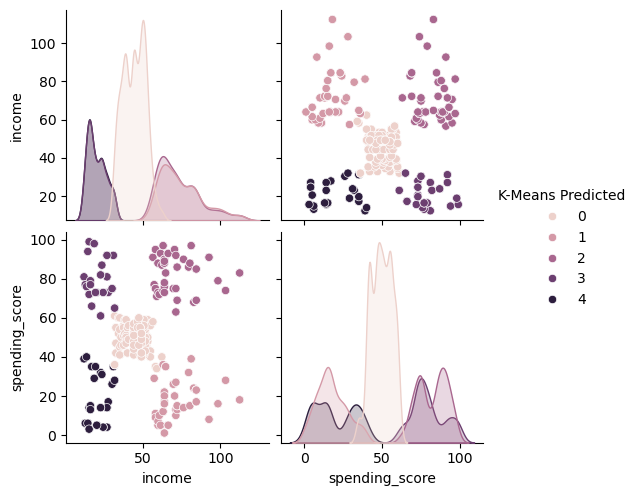

In [53]:
# Using k=5.
kmeans = KMeans(n_clusters = 5,
                max_iter = 15000,
                init = 'k-means++',
                random_state=0).fit(x)

clusters = kmeans.labels_

x['K-Means Predicted'] = clusters

# Plot the predicted. 
sns.pairplot(x,
             hue='K-Means Predicted',
             diag_kind='kde')

# Check the number of observations per predicted class.
x['K-Means Predicted'].value_counts()

K-Means Predicted
0    767
2    356
4    271
3    269
1    214
5    123
Name: count, dtype: int64

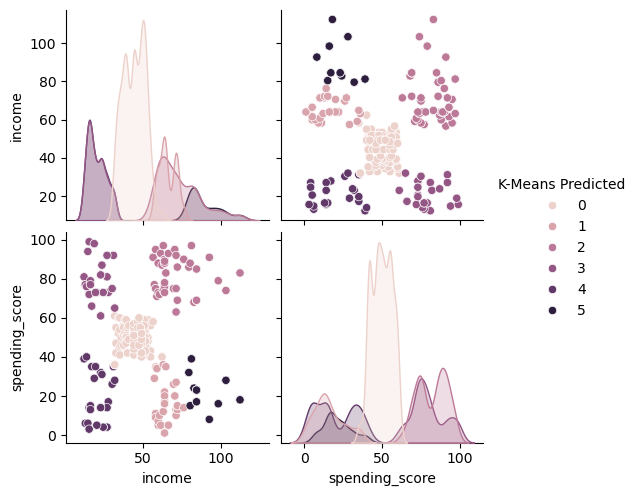

In [54]:
# Checking for k=6 just for posterity.
# Using k=6.
kmeans = KMeans(n_clusters = 6,
                max_iter = 15000,
                init = 'k-means++',
                random_state=0).fit(x)

clusters = kmeans.labels_

x['K-Means Predicted'] = clusters

# Plot the predicted. 
sns.pairplot(x,
             hue='K-Means Predicted',
             diag_kind='kde')

# Check the number of observations per predicted class.
x['K-Means Predicted'].value_counts()

K-Means Predicted
0    767
4    271
3    269
2    238
1    214
6    123
5    118
Name: count, dtype: int64

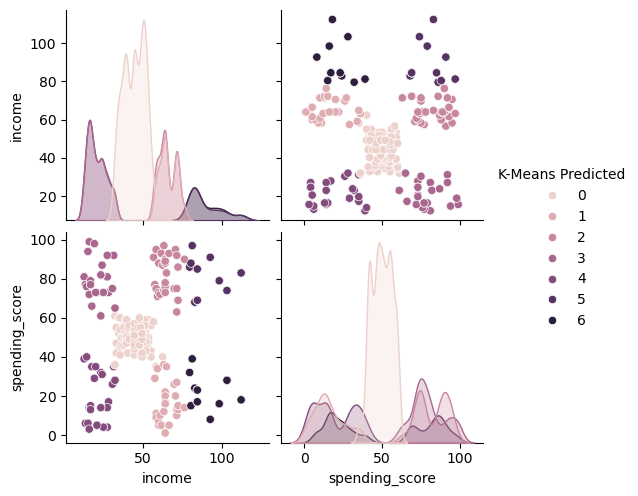

In [55]:
# check for k=7 for comfort.
# Using k=7
kmeans = KMeans(n_clusters = 7,
                max_iter = 15000,
                init = 'k-means++',
                random_state=0).fit(x)

clusters = kmeans.labels_

x['K-Means Predicted'] = clusters

# Plot the predicted. 
sns.pairplot(x,
             hue='K-Means Predicted',
             diag_kind='kde')

# Check the number of observations per predicted class.
x['K-Means Predicted'].value_counts()

There is little change between k6 and k7. I think k5 is the correct choice.

## 5. Fit final model and justify your choice

K-Means Predicted
0    774
4    356
2    330
3    271
1    269
Name: count, dtype: int64

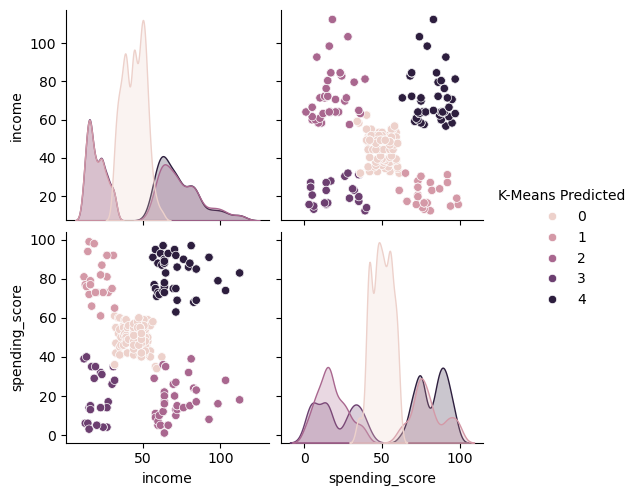

In [56]:
# Apply the final model.
# Refit k = 5 to keep variables correct.
# Using k=5.
kmeans = KMeans(n_clusters = 5,
                max_iter = 15000,
                init = 'k-means++',
                random_state=0).fit(x)

clusters = kmeans.labels_

x['K-Means Predicted'] = clusters

# Plot the predicted. 
sns.pairplot(x,
             hue='K-Means Predicted',
             diag_kind='kde')

# Check the number of observations per predicted class.
x['K-Means Predicted'].value_counts()

In [57]:
# View x DataFrame.
x.head()

,income,spending_score,K-Means Predicted
0,12.30,39,3
1,12.30,81,1
2,13.12,6,3
3,13.12,77,1
4,13.94,40,3


In [58]:
# Creat a new DataFrame from the csv file.
turtle4 = pd.read_csv('turtle_clean.csv')

# View the DataFrame.
turtle4.head()

,gender,age,income,spending_score,loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


In [59]:
# Combine the K-means predicted column to the original data.
turtle4['k-means_cluster'] = x['K-Means Predicted']

# View the newly combined DataFrame.
turtle4.head()

,gender,age,income,spending_score,loyalty_points,education,product,review,summary,k-means_cluster
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...,3
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...,1
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless",3
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars,1
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap,3


This is for preparation for the sentiment analysis that follows.

## 6. Plot and interpret the clusters

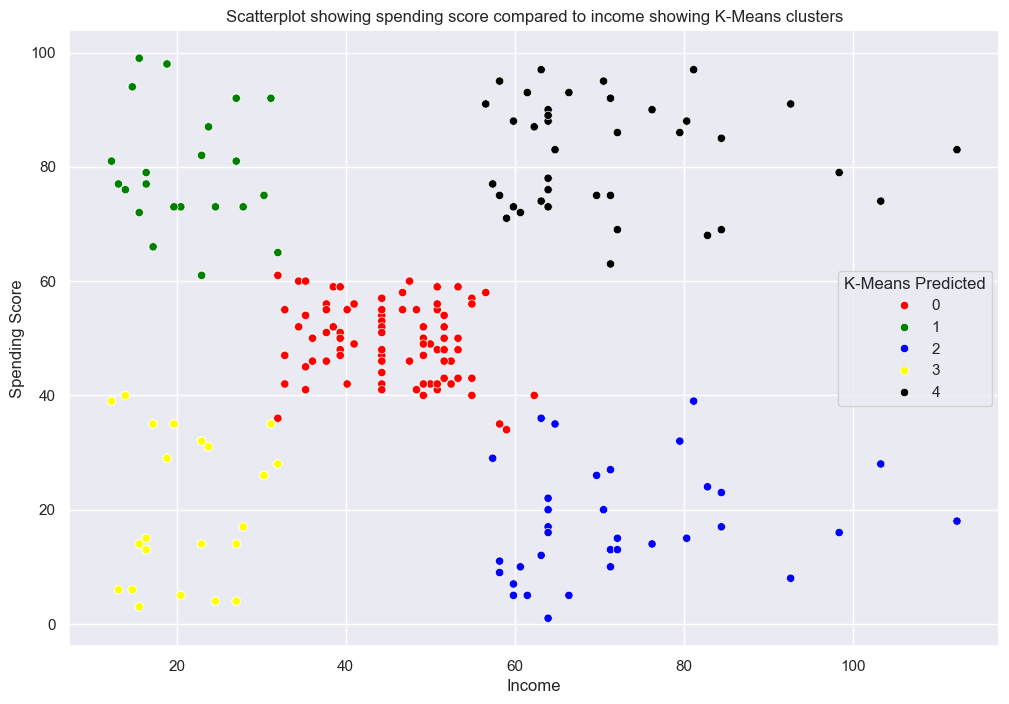

In [60]:
# Visualising the clusters.
# Set plot size.
sns.set(rc = {'figure.figsize':(12, 8)})

# Create a scatterplot.
sns.scatterplot(x='income' , 
                y ='spending_score',
                data=x,
                hue='K-Means Predicted',
                palette=['red', 'green', 'blue', 'yellow', 'black'],)

plt.title("Scatterplot showing spending score compared to income showing K-Means clusters")
plt.xlabel("Income")
plt.ylabel("Spending Score")

plt.show()

There are five clusters with some little overlap from the 0th cluster. There other four clusters are distinct from each other. 

## 7. Discuss: Insights and observations

***Your observations here...***

There are five clusters. One central cluster with a lot of observations (774), and another four clusters with between 250 and 350 observations.

# 

# Week 4 assignment: NLP using Python
Customer reviews were downloaded from the website of Turtle Games. This data will be used to steer the marketing department on how to approach future campaigns. Therefore, the marketing department asked you to identify the 15 most common words used in online product reviews. They also want to have a list of the top 20 positive and negative reviews received from the website. Therefore, you need to apply NLP on the data set.

## Instructions
1. Load and explore the data. 
    1. Sense-check the DataFrame.
    2. You only need to retain the `review` and `summary` columns.
    3. Determine if there are any missing values.
2. Prepare the data for NLP
    1. Change to lower case and join the elements in each of the columns respectively (`review` and `summary`).
    2. Replace punctuation in each of the columns respectively (`review` and `summary`).
    3. Drop duplicates in both columns (`review` and `summary`).
3. Tokenise and create wordclouds for the respective columns (separately).
    1. Create a copy of the DataFrame.
    2. Apply tokenisation on both columns.
    3. Create and plot a wordcloud image.
4. Frequency distribution and polarity.
    1. Create frequency distribution.
    2. Remove alphanumeric characters and stopwords.
    3. Create wordcloud without stopwords.
    4. Identify 15 most common words and polarity.
5. Review polarity and sentiment.
    1. Plot histograms of polarity (use 15 bins) for both columns.
    2. Review the sentiment scores for the respective columns.
6. Identify and print the top 20 positive and negative reviews and summaries respectively.
7. Include your insights and observations.

## 1. Load and explore the data

In [61]:
# Import all the necessary packages.
import pandas as pd
import numpy as np
import nltk 
import os 
import matplotlib.pyplot as plt

# nltk.download ('punkt').
# nltk.download ('stopwords').

from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import stopwords
from textblob import TextBlob
from scipy.stats import norm

# Import Counter.
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

In [62]:
# Created the new data frame from previous activity.
# View DataFrame.
turtle4.head()

,gender,age,income,spending_score,loyalty_points,education,product,review,summary,k-means_cluster
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...,3
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...,1
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless",3
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars,1
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap,3


In [63]:
# Explore data set.
print(turtle4.info())
print(turtle4.describe)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           2000 non-null   object 
 1   age              2000 non-null   int64  
 2   income           2000 non-null   float64
 3   spending_score   2000 non-null   int64  
 4   loyalty_points   2000 non-null   int64  
 5   education        2000 non-null   object 
 6   product          2000 non-null   int64  
 7   review           2000 non-null   object 
 8   summary          2000 non-null   object 
 9   k-means_cluster  2000 non-null   int32  
dtypes: float64(1), int32(1), int64(4), object(4)
memory usage: 148.6+ KB
None
<bound method NDFrame.describe of       gender  age  income  spending_score  loyalty_points education  product  \
0       Male   18   12.30              39             210  graduate      453   
1       Male   23   12.30              81             524  graduate 

In [64]:
# Keep necessary columns. Drop unnecessary columns.
# Create new data frame for NLP.
turtle_NLP = turtle4[['review', 'summary']]

# View DataFrame.
turtle_NLP.head()


,review,summary
0,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,As my review of GF9's previous screens these w...,Money trap


In [65]:
# Determine if there are any missing values.
turtle_NLP.isnull().sum()

review     0
summary    0
dtype: int64

There are no missing values.

## 2. Prepare the data for NLP
### 2a) Change to lower case and join the elements in each of the columns respectively (review and summary)

In [66]:
# Review: Change all to lower case and join with a space.
turtle_NLP['review'] = turtle_NLP['review'].apply(lambda x: " ".join(x.lower() for x in x.split()))

# Preview the result.
turtle_NLP['review'].head()

0    when it comes to a dm's screen, the space on t...
1    an open letter to galeforce9*: your unpainted ...
2    nice art, nice printing. why two panels are fi...
3    amazing buy! bought it as a gift for our new d...
4    as my review of gf9's previous screens these w...
Name: review, dtype: object

In [67]:
# Summary: Change all to lower case and join with a space.
turtle_NLP['summary'] = turtle_NLP['summary'].apply(lambda x: " ".join(x.lower() for x in x.split()))

# Preview the result.
turtle_NLP['summary'].head()

0    the fact that 50% of this space is wasted on a...
1    another worthless dungeon master's screen from...
2                      pretty, but also pretty useless
3                                           five stars
4                                           money trap
Name: summary, dtype: object

### 2b) Replace punctuation in each of the columns respectively (review and summary)

In [68]:
# Replace all the punctuations in review column.
turtle_NLP['review'] = turtle_NLP['review'].str.replace('[^\w\s]','', regex=True)

# View output.
turtle_NLP['review'].head()


0    when it comes to a dms screen the space on the...
1    an open letter to galeforce9 your unpainted mi...
2    nice art nice printing why two panels are fill...
3    amazing buy bought it as a gift for our new dm...
4    as my review of gf9s previous screens these we...
Name: review, dtype: object

In [69]:
# Replace all the puncuations in summary column.
turtle_NLP['summary'] = turtle_NLP['summary'].str.replace('[^\w\s]','', regex=True)

# View output.
turtle_NLP['summary'].head()

0    the fact that 50 of this space is wasted on ar...
1    another worthless dungeon masters screen from ...
2                       pretty but also pretty useless
3                                           five stars
4                                           money trap
Name: summary, dtype: object

### 2c) Drop duplicates in both columns

In [70]:
# Check the number of duplicate values in the review column.
print(turtle_NLP.review.duplicated().sum())

50


In [71]:
# Check the number of duplicate values in the summary column.
print(turtle_NLP.summary.duplicated().sum())

649


In [72]:
# Drop duplicates in both columns.
Review_Summary = turtle_NLP.drop_duplicates(subset=['review', 'summary'])

# View DataFrame.
Review_Summary.reset_index(inplace=True)
Review_Summary.head()

,index,review,summary
0,0,when it comes to a dms screen the space on the...,the fact that 50 of this space is wasted on ar...
1,1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon masters screen from ...
2,2,nice art nice printing why two panels are fill...,pretty but also pretty useless
3,3,amazing buy bought it as a gift for our new dm...,five stars
4,4,as my review of gf9s previous screens these we...,money trap


## 3. Tokenise and create wordclouds

In [73]:
# Create new DataFrame (copy DataFrame).
turtle_NLP_token = turtle_NLP.copy()

# View DataFrame.
turtle_NLP_token

,review,summary
0,when it comes to a dms screen the space on the...,the fact that 50 of this space is wasted on ar...
1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon masters screen from ...
2,nice art nice printing why two panels are fill...,pretty but also pretty useless
3,amazing buy bought it as a gift for our new dm...,five stars
4,as my review of gf9s previous screens these we...,money trap
...,...,...
1995,the perfect word game for mixed ages with mom ...,the perfect word game for mixed ages with mom
1996,great game did not think i would like it when ...,super fun
1997,great game for all keeps the mind nimble,great game
1998,fun game,four stars


In [74]:
# Tokenise the words.
turtle_NLP_token['Review Token'] = turtle_NLP_token['review'].apply(word_tokenize)
turtle_NLP_token['Summary Token'] = turtle_NLP_token['summary'].apply(word_tokenize)

# View the new DataFrame.
turtle_NLP_token.head()

,review,summary,Review Token,Summary Token
0,when it comes to a dms screen the space on the...,the fact that 50 of this space is wasted on ar...,"[when, it, comes, to, a, dms, screen, the, spa...","[the, fact, that, 50, of, this, space, is, was..."
1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon masters screen from ...,"[an, open, letter, to, galeforce9, your, unpai...","[another, worthless, dungeon, masters, screen,..."
2,nice art nice printing why two panels are fill...,pretty but also pretty useless,"[nice, art, nice, printing, why, two, panels, ...","[pretty, but, also, pretty, useless]"
3,amazing buy bought it as a gift for our new dm...,five stars,"[amazing, buy, bought, it, as, a, gift, for, o...","[five, stars]"
4,as my review of gf9s previous screens these we...,money trap,"[as, my, review, of, gf9s, previous, screens, ...","[money, trap]"


In [75]:
# Create a review token variable.
Review_token = turtle_NLP_token['Review Token']

# Create a summary token variable.
Summary_token = turtle_NLP_token['Summary Token']

In [76]:
# Define a string of tokens
Review_token = []

for i in range(turtle_NLP_token.shape[0]):
    # Add each token to the string.
    Review_token = Review_token + turtle_NLP_token['Review Token'][i]

In [77]:
# Make into a string.
Review_token_str = " ".join(Review_token)

# View string.
Review_token_str

'when it comes to a dms screen the space on the screen itself is at an absolute premium the fact that 50 of this space is wasted on art and not terribly informative or needed art as well makes it completely useless the only reason that i gave it 2 stars and not 1 was that technically speaking it can at least still stand up to block your notes and dice rolls other than that it drops the ball completely an open letter to galeforce9 your unpainted miniatures are very not bad your spell cards are great your board games are meh your dm screens however are freaking terrible im still waiting for a single screen that isnt polluted with pointless artwork where useful referenceable tables should be once again youve created a single use screen that is only useful when running the storm kings thunder adventure even despite the fact that its geared to that adventure path its usefulness negligible at best i massive swath of the inner panel is wasted on artwork and a bloated overland map which could 

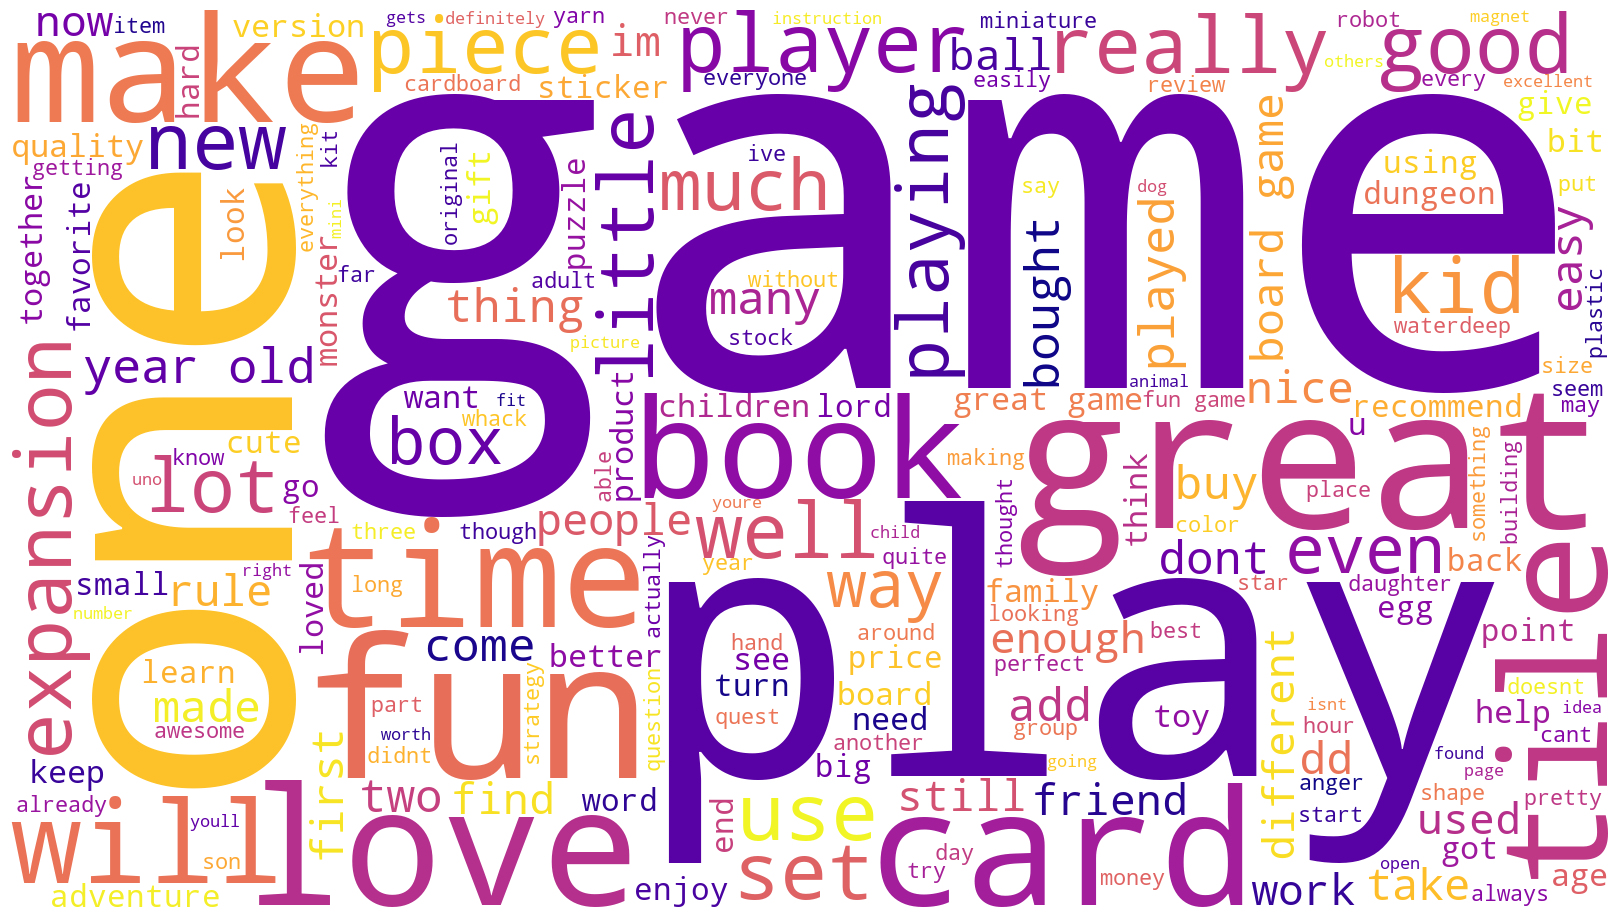

In [78]:
# Review: Create a word cloud.
wordcloud = WordCloud(width = 1600, height = 900, 
                background_color ='white', 
                colormap='plasma', 
                min_font_size = 10).generate(Review_token_str) 

# Plot the WordCloud image.                        
plt.figure(figsize = (16, 9), facecolor = None) 
plt.imshow(wordcloud) 
plt.axis('off') 
plt.tight_layout(pad = 0) 
plt.show()



This word cloud for the review column shows that the playing and great are popular words. There are also stop words that need to be removed.

In [79]:
# Define an empty list of tokens. 
Summary_token = []

for i in range(turtle_NLP_token.shape[0]):
    # Add each token to the list.
    Summary_token = Summary_token + turtle_NLP_token['Summary Token'][i]

# Convert the list to a string.
Summary_token_str = " ".join(Summary_token)

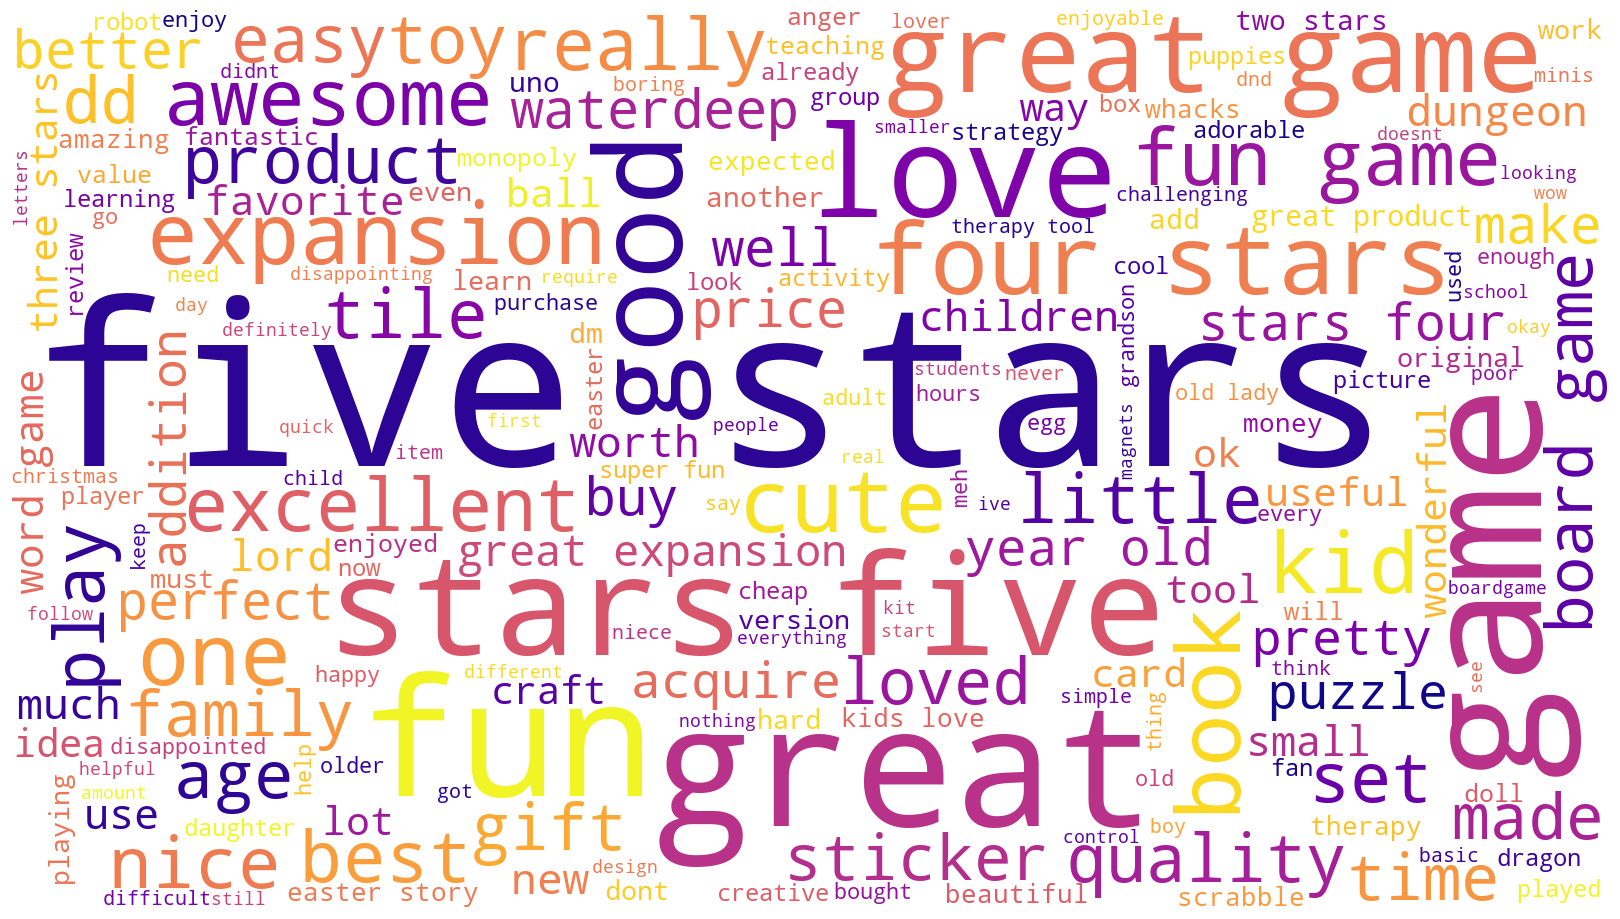

In [80]:
# Summary: Create a word cloud.
wordcloud = WordCloud(width = 1600, height = 900, 
                background_color ='white', 
                colormap='plasma', 
                min_font_size = 10).generate(Summary_token_str) 

# Plot the WordCloud image.                        
plt.figure(figsize = (16, 9), facecolor = None) 
plt.imshow(wordcloud) 
plt.axis('off') 
plt.tight_layout(pad = 0) 
plt.show()

This is a word cloud for the summary column showing a sentiment towards games and playing - similar to the review column. There are also stop words involved.

## 4. Frequency distribution and polarity
### 4a) Create frequency distribution

In [81]:
# Determine the frequency distribution for Review_token
fdist_review = FreqDist(Review_token)

# Preview data.
fdist_review

FreqDist({'the': 5452, 'and': 3234, 'to': 3164, 'a': 3161, 'of': 2488, 'i': 2091, 'it': 2090, 'is': 1782, 'this': 1776, 'game': 1685, ...})

In [82]:
# View the top 10 words.
fdist_review.most_common(10)

[('the', 5452),
 ('and', 3234),
 ('to', 3164),
 ('a', 3161),
 ('of', 2488),
 ('i', 2091),
 ('it', 2090),
 ('is', 1782),
 ('this', 1776),
 ('game', 1685)]

There are a lot of stop words involved.

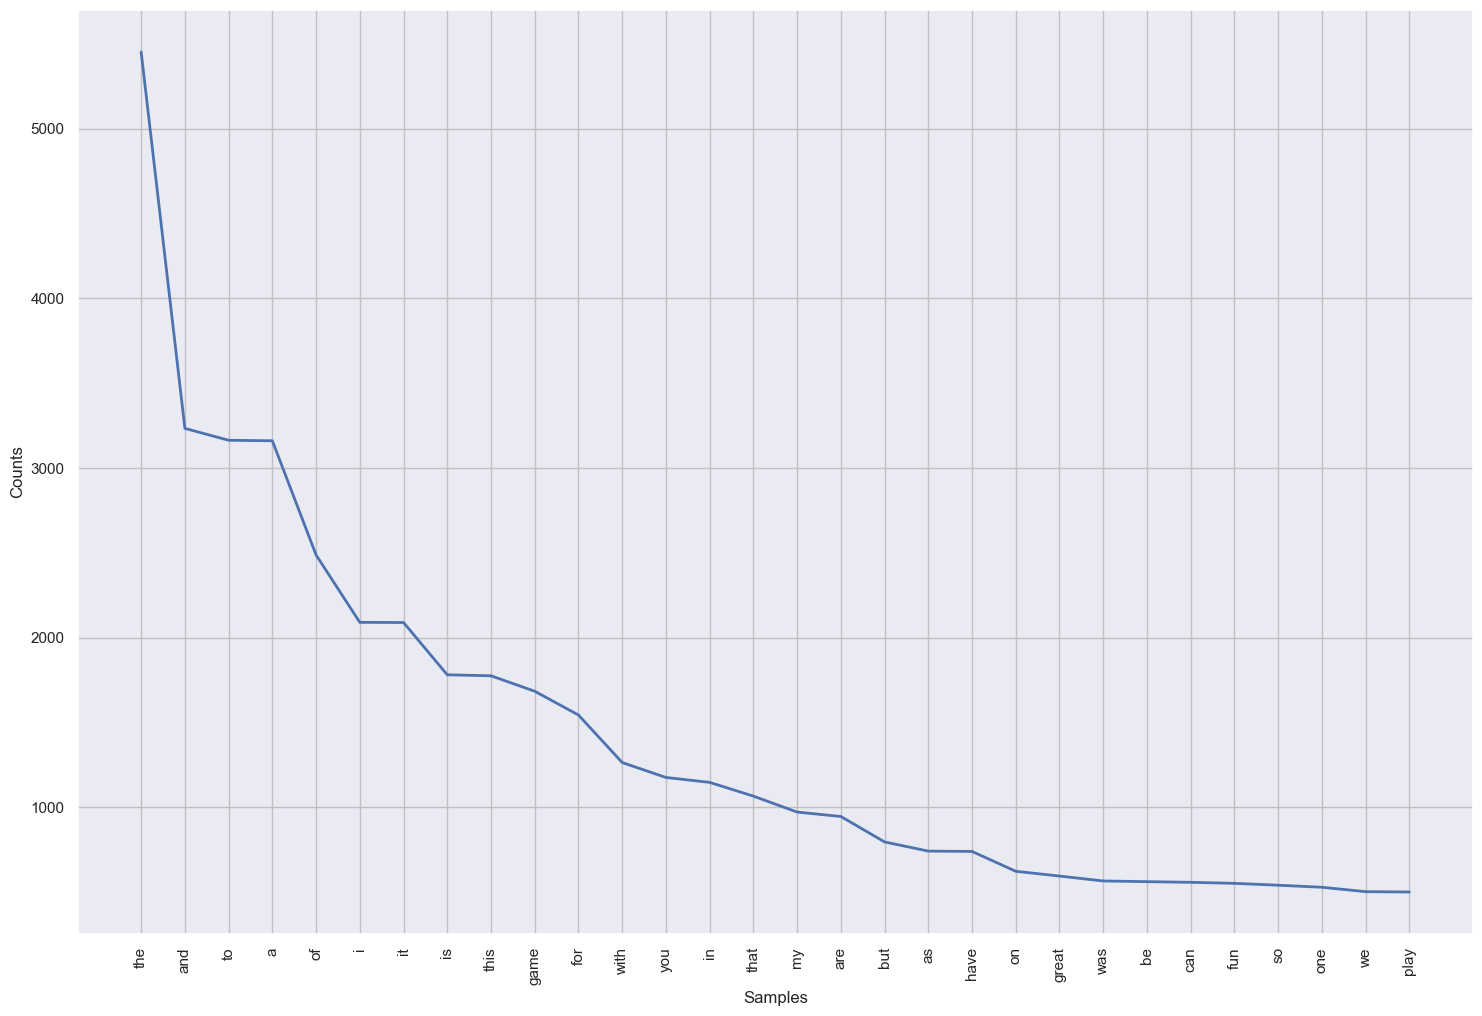

In [83]:
# Plot the most common words in 'review'
# Define the figure and axes.
fig, ax = plt.subplots(dpi=100)
fig.set_size_inches(18, 12)

# Plot the data set.
fdist_review.plot(30, cumulative=False);

Mostly stop words in the frequency chart.

In [84]:
# Determine the frequency distribution for Review_token
fdist_summary = FreqDist(Summary_token)

# Preview data.
fdist_summary

FreqDist({'stars': 466, 'five': 381, 'game': 319, 'great': 295, 'the': 261, 'a': 240, 'for': 232, 'fun': 218, 'to': 192, 'and': 168, ...})

In [85]:
# View the top 10 words.
fdist_summary.most_common(10)

[('stars', 466),
 ('five', 381),
 ('game', 319),
 ('great', 295),
 ('the', 261),
 ('a', 240),
 ('for', 232),
 ('fun', 218),
 ('to', 192),
 ('and', 168)]

There are some stop words, but the most common word is still relevant.

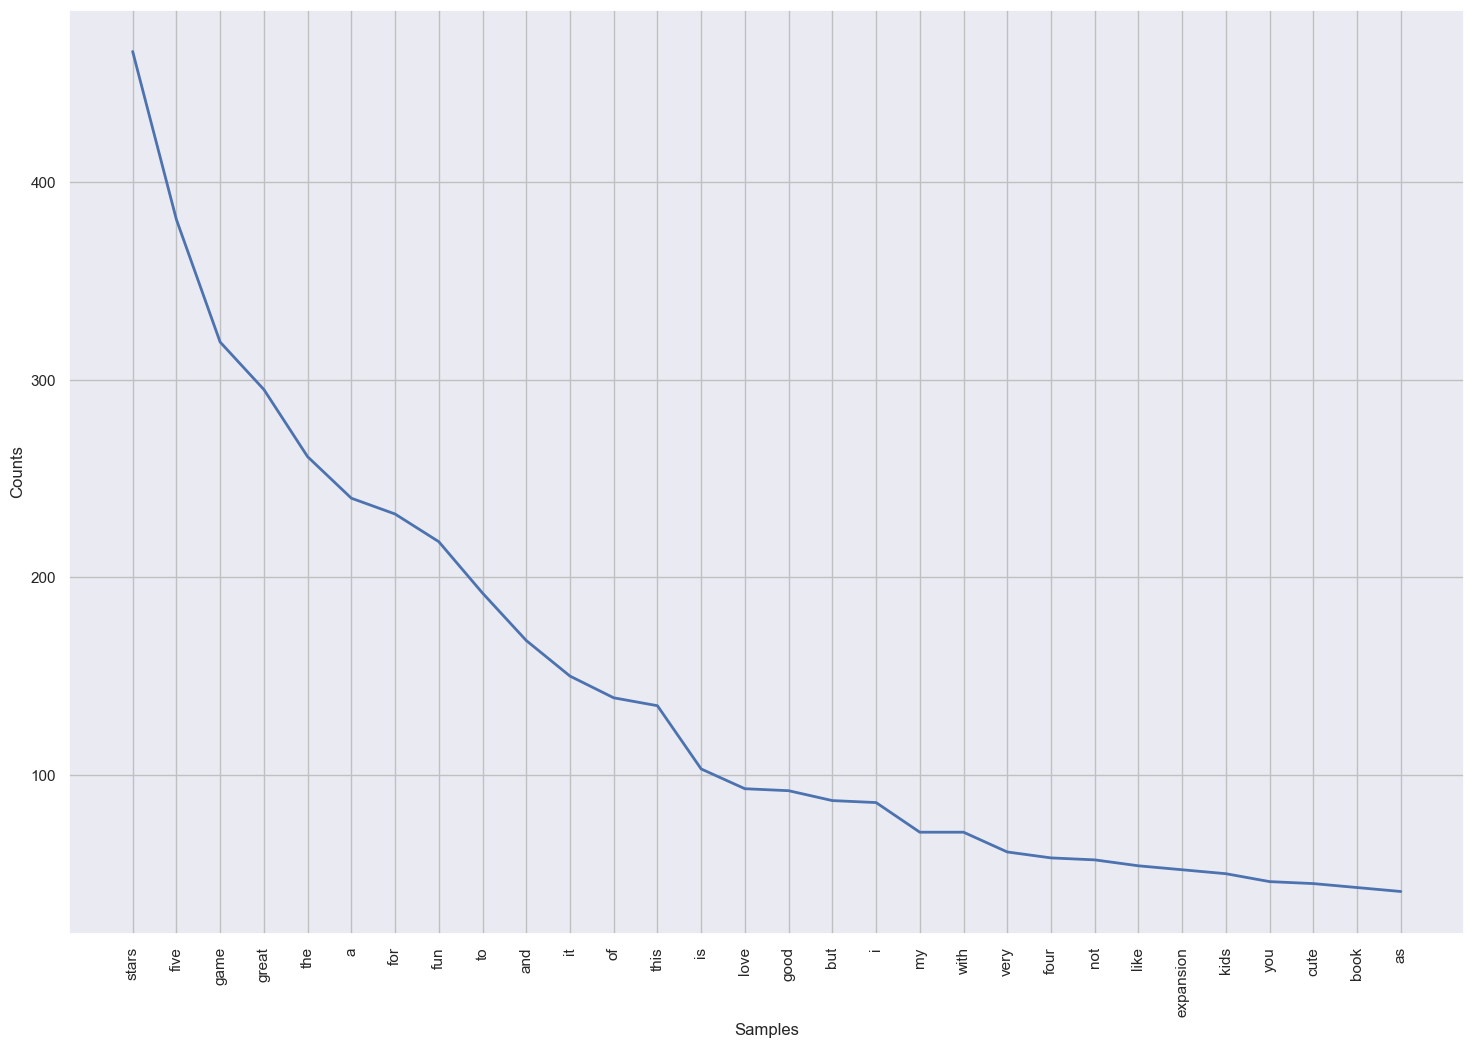

In [86]:
# Plot the most common words in 'summary'
# Define the figure and axes.
fig, ax = plt.subplots(dpi=100)
fig.set_size_inches(18, 12)

# Plot the data set.
fdist_summary.plot(30, cumulative=False);

A frequency distribution showing the most popular words in the summary column. There are stop words in the distribution, but the most frequent word is 'stars' which would be appropriate when people are giving a star rating between 1 and 5.

### 4b) Remove alphanumeric characters and stopwords

In [87]:
# Delete all the alpanum in review
# After tokenizing, keep only tokens that have at least one letter
meaningful_review = [word for word in Review_token if any(char.isalpha() for char in word)]
meaningful_summary = [word for word in Summary_token if any(char.isalpha() for char in word)]

In [88]:
# Remove all the stopwords
# Download the stopword list.
nltk.download ('stopwords')
from nltk.corpus import stopwords

# Create a set of English stopwords.
english_stopwords = set(stopwords.words('english'))

# Create a filtered list of tokens without stopwords.
meaningful_review2 = [x for x in meaningful_review if x.lower() not in english_stopwords]

# Define an empty string variable.
meaningful_review2_string = ''

for value in meaningful_review:
    # Add each filtered token word to the string.
    meaningful_review2_string = meaningful_review2_string + value + ' '

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gebre\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [89]:
# Create a filtered list of tokens without stopwords.
meaningful_summary2 = [x for x in meaningful_summary if x.lower() not in english_stopwords]

# Define an empty string variable.
meaningful_summary2_str = ''

for value in meaningful_summary:
    # Add each filtered token word to the string.
    meaningful_summary2_str = meaningful_summary2_str + value + ' '

### 4c) Create wordcloud without stopwords

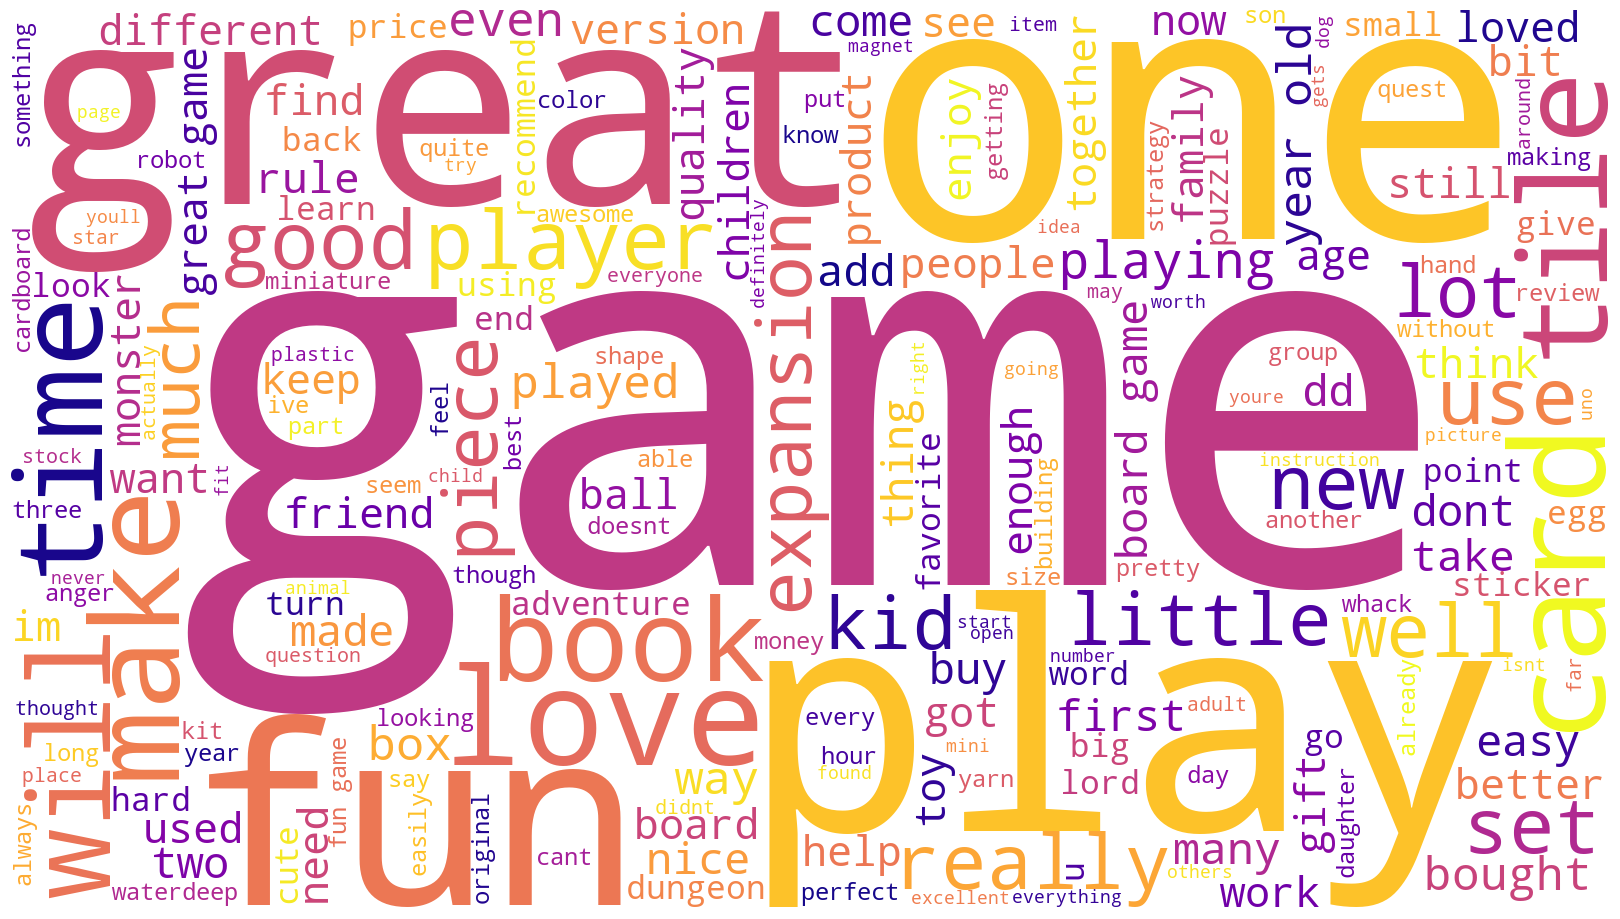

In [90]:
# Create a wordcloud without stop words.
# For review: Create a word cloud
wordcloud = WordCloud(width = 1600, height = 900, 
                background_color ='white', 
                colormap='plasma', 
                min_font_size = 10).generate(meaningful_review2_string) 

# Plot the WordCloud image.                        
plt.figure(figsize = (16, 9), facecolor = None) 
plt.imshow(wordcloud) 
plt.axis('off') 
plt.tight_layout(pad = 0) 
plt.show()

Game and play are very large. This is conducive with reviews at a game shop. There are also some positive words - i.e. love and great.

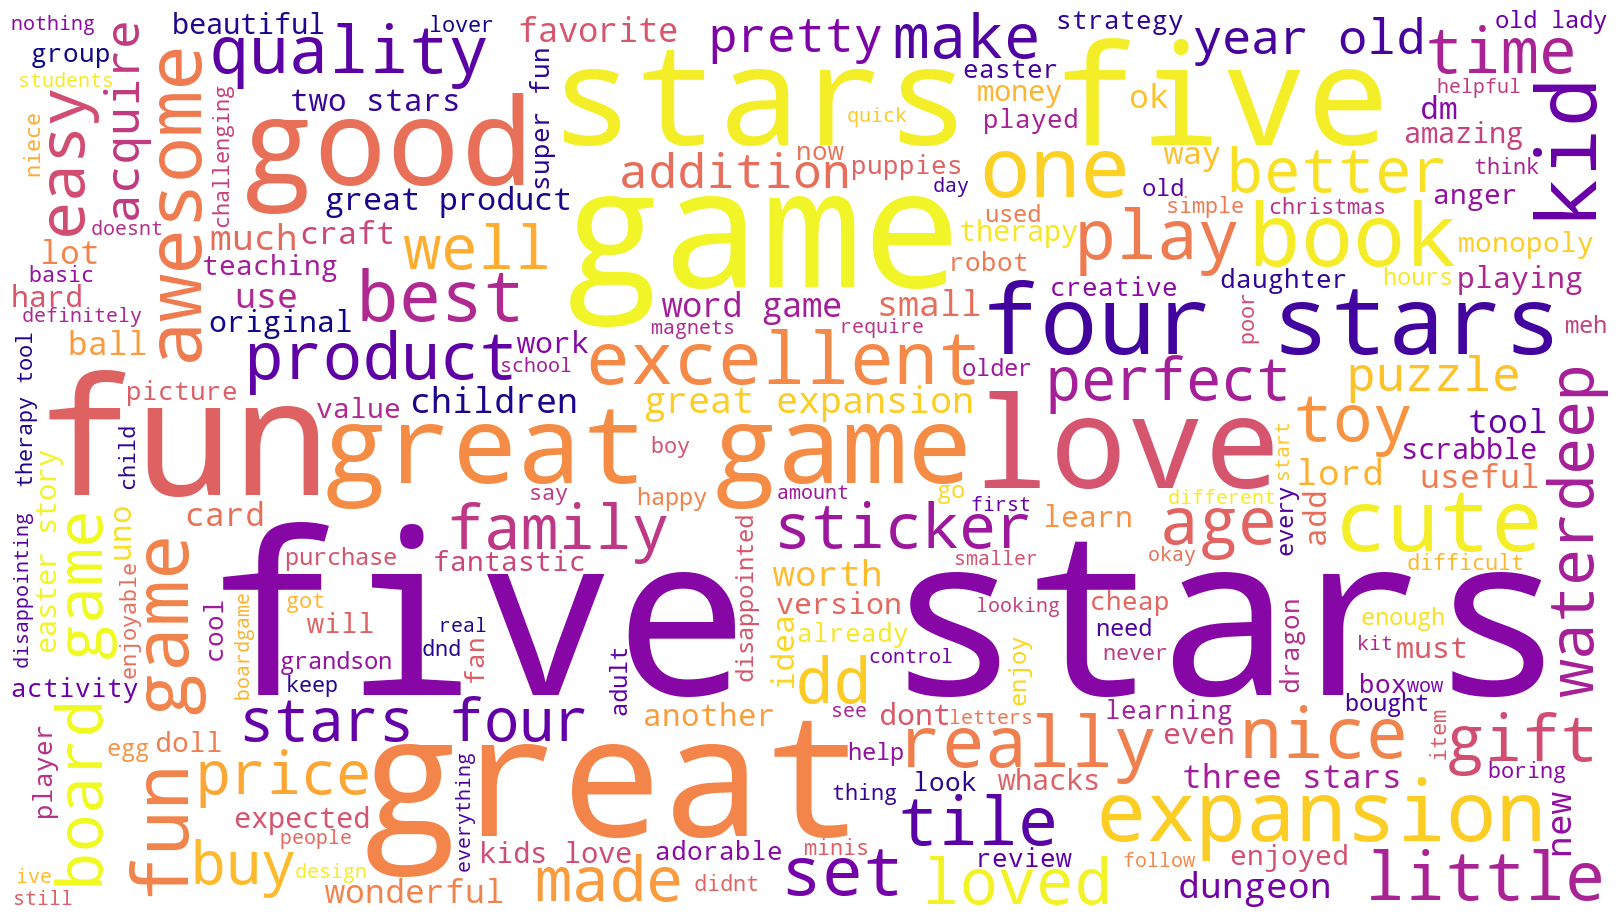

In [91]:
# Summary: Create a word cloud.
wordcloud = WordCloud(width = 1600, height = 900, 
                background_color ='white', 
                colormap='plasma', 
                min_font_size = 10).generate(meaningful_summary2_str) 

# Plot the WordCloud image.                        
plt.figure(figsize = (16, 9), facecolor = None) 
plt.imshow(wordcloud) 
plt.axis('off') 
plt.tight_layout(pad = 0) 
plt.show()

five stars is large. Maybe people used the summary as a review?

### 4d) Identify 15 most common words and polarity

In [92]:
# For review:
# Frequency distribution of review without stopwords.
meaningful_review_fdist = FreqDist(meaningful_review2)

# Preview data
meaningful_review_fdist

FreqDist({'game': 1685, 'great': 596, 'fun': 553, 'one': 530, 'play': 502, 'like': 414, 'love': 331, 'really': 319, 'get': 319, 'cards': 301, ...})

In [93]:
# Import the Counter class.
from collections import Counter

# Generate a DataFrame from Counter.
countsReview = pd.DataFrame(Counter(meaningful_review2).items(),
                      columns=['Word', 'Frequency']).sort_values('Frequency', ascending=False).set_index('Word')

# Preview data.
countsReview.head(15)

,Frequency
Word,
game,1685
great,596
fun,553
one,530
play,502
like,414
love,331
get,319
really,319


A Pandas Series showing the 15 most common words in the review column after the stop words were removed.  There are mostly words regarding fun and playing.

In [94]:
# Determine the 15 most common in review.
meaningful_review_fdist.most_common(15)

[('game', 1685),
 ('great', 596),
 ('fun', 553),
 ('one', 530),
 ('play', 502),
 ('like', 414),
 ('love', 331),
 ('really', 319),
 ('get', 319),
 ('cards', 301),
 ('tiles', 297),
 ('good', 294),
 ('time', 291),
 ('would', 280),
 ('book', 273)]

The most common words in review relay enjoyment and specifying the type of game.

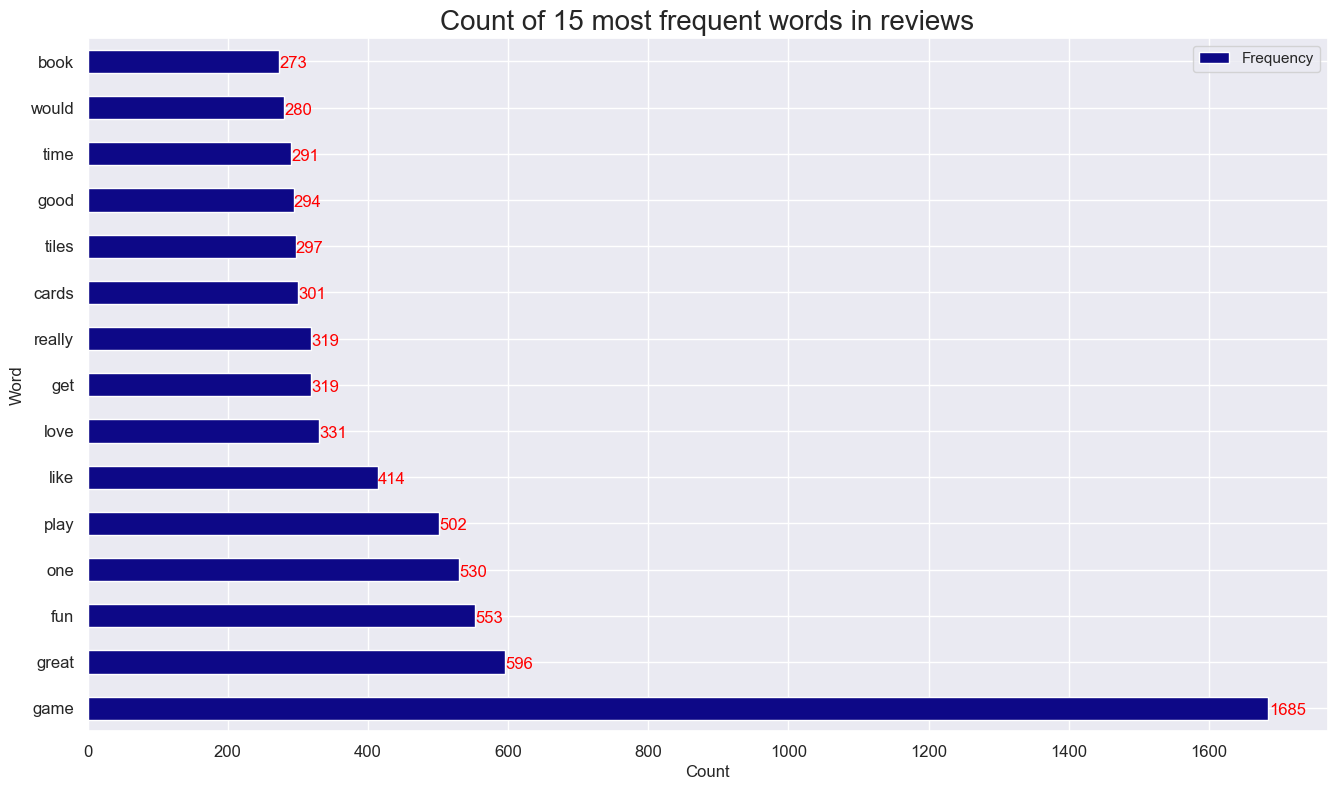

In [95]:
# Set the plot type.
ax = countsReview.head(15).plot(kind='barh', figsize=(16, 9), fontsize=12,
                 colormap ='plasma')

# Set the labels.
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Word', fontsize=12)
ax.set_title("Count of 15 most frequent words in reviews",
             fontsize=20)

# Draw the bar labels.
for i in ax.patches:
    ax.text(i.get_width()+.41, i.get_y()+.1, str(round((i.get_width()), 2)),
            fontsize=12, color='red')

A bar plot to show the 15 most common words.

In [96]:
# For summary:
# Frequency distribution of summary without stopwords.
meaningful_summary_fdist = FreqDist(meaningful_summary2)

# Preview data.
meaningful_summary_fdist

FreqDist({'stars': 466, 'five': 381, 'game': 319, 'great': 295, 'fun': 218, 'love': 93, 'good': 92, 'four': 58, 'like': 54, 'expansion': 52, ...})

In [97]:
# Import the Counter class.
from collections import Counter

# Generate a DataFrame from Counter.
countsSummary = pd.DataFrame(Counter(meaningful_summary2).items(),
                      columns=['Word', 'Frequency']).sort_values('Frequency', ascending=False).set_index('Word')

# Preview data.
countsSummary.head(15)

,Frequency
Word,
stars,466
five,381
game,319
great,295
fun,218
love,93
good,92
four,58
like,54


This is a Pandas Series showing the top 15 most common words in the summary column after the stop words were removed. Stars is the most common word and then five is second, which suggests people are putting mostly five star ratings in the summary column.

In [98]:
# Determine the 15 most common words in summary.
meaningful_summary_fdist.most_common(15)

[('stars', 466),
 ('five', 381),
 ('game', 319),
 ('great', 295),
 ('fun', 218),
 ('love', 93),
 ('good', 92),
 ('four', 58),
 ('like', 54),
 ('expansion', 52),
 ('kids', 50),
 ('cute', 45),
 ('book', 43),
 ('one', 38),
 ('awesome', 36)]

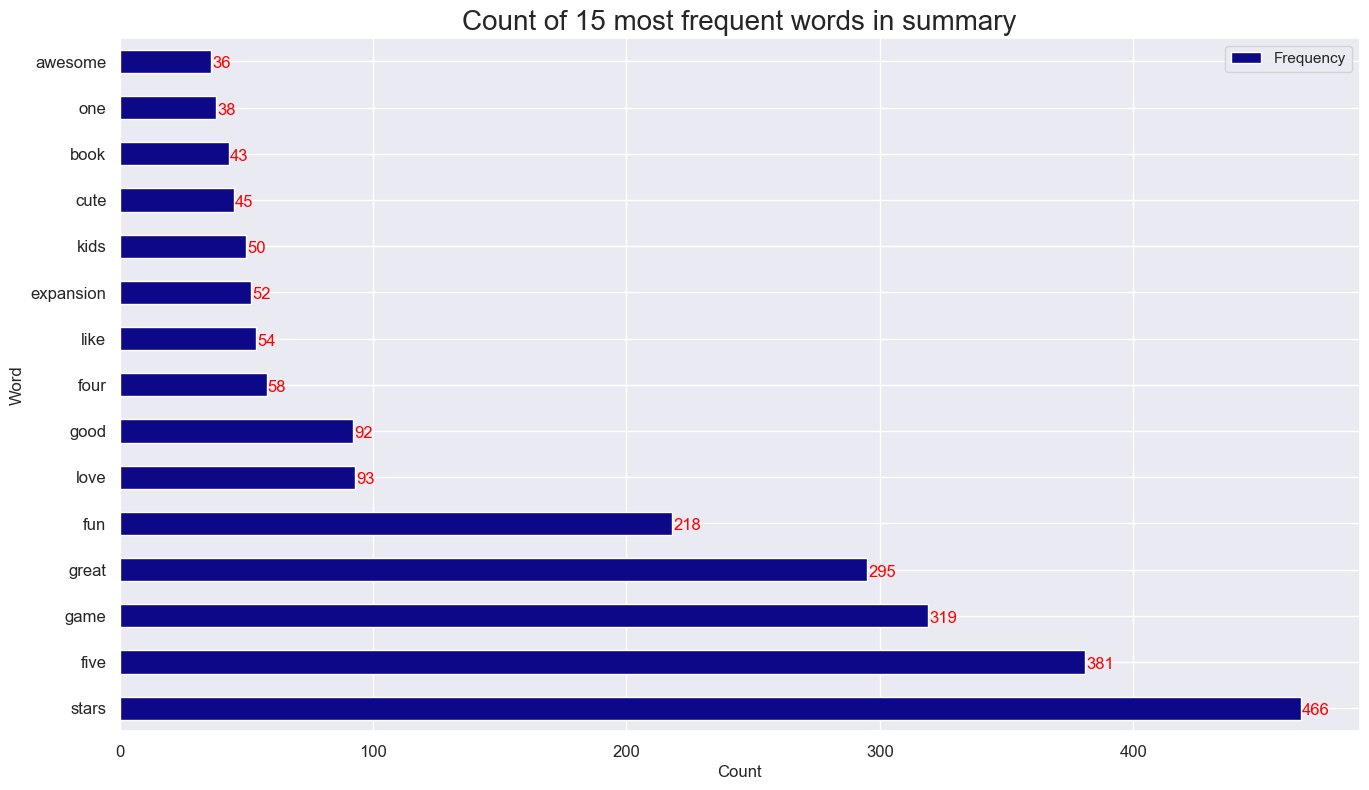

In [99]:
# Set the plot type.
ax = countsSummary.head(15).plot(kind='barh', figsize=(16, 9), fontsize=12,
                 colormap ='plasma')

# Set the labels.
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Word', fontsize=12)
ax.set_title("Count of 15 most frequent words in summary",
             fontsize=20)

# Draw the bar labels.
for i in ax.patches:
    ax.text(i.get_width()+.41, i.get_y()+.1, str(round((i.get_width()), 2)),
            fontsize=12, color='red')

A bar plot to show the 15 most common words in summary.

In [100]:
# Determine polarity of top 15 review words.
# Make a new DataFrame from counts.
ReviewPolarity = countsReview.reset_index()

# Import the necessary package.
from textblob import TextBlob

# Define a function to extract a polarity score 
def generate_polarity(comment):
    return TextBlob(comment).sentiment[0]

# Populate a new column with polarity scores for each comment.
ReviewPolarity['polarity'] = ReviewPolarity['Word'].apply(generate_polarity)

# Preview the result.
ReviewPolarity.head(15)

,Word,Frequency,polarity
0,game,1685,-0.4
1,great,596,0.8
2,fun,553,0.3
3,one,530,0.0
4,play,502,0.0
5,like,414,0.0
6,love,331,0.5
7,get,319,0.0
8,really,319,0.2
9,cards,301,0.0


This is a DataFrame shoing the polarity of the indvidual words that are most common in the review column. Mostly 0.0, which would make sense because individual words would not necessarily hold much sentiment. Curioulsy, game has a negative sentiment which would not be appropriate for a games company. 

In [101]:
# Determine polarity of top 15 summary words.
# Make a new DataFrame from counts.
SummaryPolarity = countsSummary.reset_index()

# Populate a new column with polarity scores for each comment.
SummaryPolarity['polarity'] = SummaryPolarity['Word'].apply(generate_polarity)

# Preview the result.
SummaryPolarity.head(15)

,Word,Frequency,polarity
0,stars,466,0.0
1,five,381,0.0
2,game,319,-0.4
3,great,295,0.8
4,fun,218,0.3
5,love,93,0.5
6,good,92,0.7
7,four,58,0.0
8,like,54,0.0
9,expansion,52,0.0


## 5. Review polarity and sentiment: Plot histograms of polarity (use 15 bins) and sentiment scores for the respective columns.

In [102]:
# Provided function.
def generate_polarity(comment):
    '''Extract polarity score (-1 to +1) for each comment'''
    return TextBlob(comment).sentiment[0]

In [103]:
# View the DataFrame that I'm working with.
turtle_NLP.head()

,review,summary
0,when it comes to a dms screen the space on the...,the fact that 50 of this space is wasted on ar...
1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon masters screen from ...
2,nice art nice printing why two panels are fill...,pretty but also pretty useless
3,amazing buy bought it as a gift for our new dm...,five stars
4,as my review of gf9s previous screens these we...,money trap


In [104]:
# Determine polarity of both columns. 
turtle_NLP['Review Polarity'] = turtle_NLP['review'].apply(generate_polarity)
turtle_NLP['Summary Polarity'] = turtle_NLP['summary'].apply(generate_polarity)
# View output.
turtle_NLP

,review,summary,Review Polarity,Summary Polarity
0,when it comes to a dms screen the space on the...,the fact that 50 of this space is wasted on ar...,-0.036111,0.150000
1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon masters screen from ...,0.035952,-0.800000
2,nice art nice printing why two panels are fill...,pretty but also pretty useless,0.116640,0.000000
3,amazing buy bought it as a gift for our new dm...,five stars,0.578788,0.000000
4,as my review of gf9s previous screens these we...,money trap,-0.316667,0.000000
...,...,...,...,...
1995,the perfect word game for mixed ages with mom ...,the perfect word game for mixed ages with mom,0.168750,0.200000
1996,great game did not think i would like it when ...,super fun,0.158333,0.316667
1997,great game for all keeps the mind nimble,great game,0.200000,0.200000
1998,fun game,four stars,-0.050000,0.000000


This is a DataFrame showing the polarity score for review and summary columns. 

In [105]:
# Define a function to determine subjectivity.
def generate_subjectivity(comment):
    '''Extract polarity score (-1 to +1) for each comment'''
    return TextBlob(comment).sentiment[1] 

In [106]:
# Determine subjectivity of both columns.
turtle_NLP['Review Subjectivity'] = turtle_NLP['review'].apply(generate_subjectivity)
turtle_NLP['Summary Subjectivity'] = turtle_NLP['summary'].apply(generate_subjectivity)

# View the DataFrame.
turtle_NLP

,review,summary,Review Polarity,Summary Polarity,Review Subjectivity,Summary Subjectivity
0,when it comes to a dms screen the space on the...,the fact that 50 of this space is wasted on ar...,-0.036111,0.150000,0.486111,0.500000
1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon masters screen from ...,0.035952,-0.800000,0.442976,0.900000
2,nice art nice printing why two panels are fill...,pretty but also pretty useless,0.116640,0.000000,0.430435,0.733333
3,amazing buy bought it as a gift for our new dm...,five stars,0.578788,0.000000,0.784848,0.000000
4,as my review of gf9s previous screens these we...,money trap,-0.316667,0.000000,0.316667,0.000000
...,...,...,...,...,...,...
1995,the perfect word game for mixed ages with mom ...,the perfect word game for mixed ages with mom,0.168750,0.200000,0.491667,0.550000
1996,great game did not think i would like it when ...,super fun,0.158333,0.316667,0.310043,0.433333
1997,great game for all keeps the mind nimble,great game,0.200000,0.200000,0.575000,0.575000
1998,fun game,four stars,-0.050000,0.000000,0.300000,0.000000


This DataFrame now has subjectivity added for the review and summary columns.

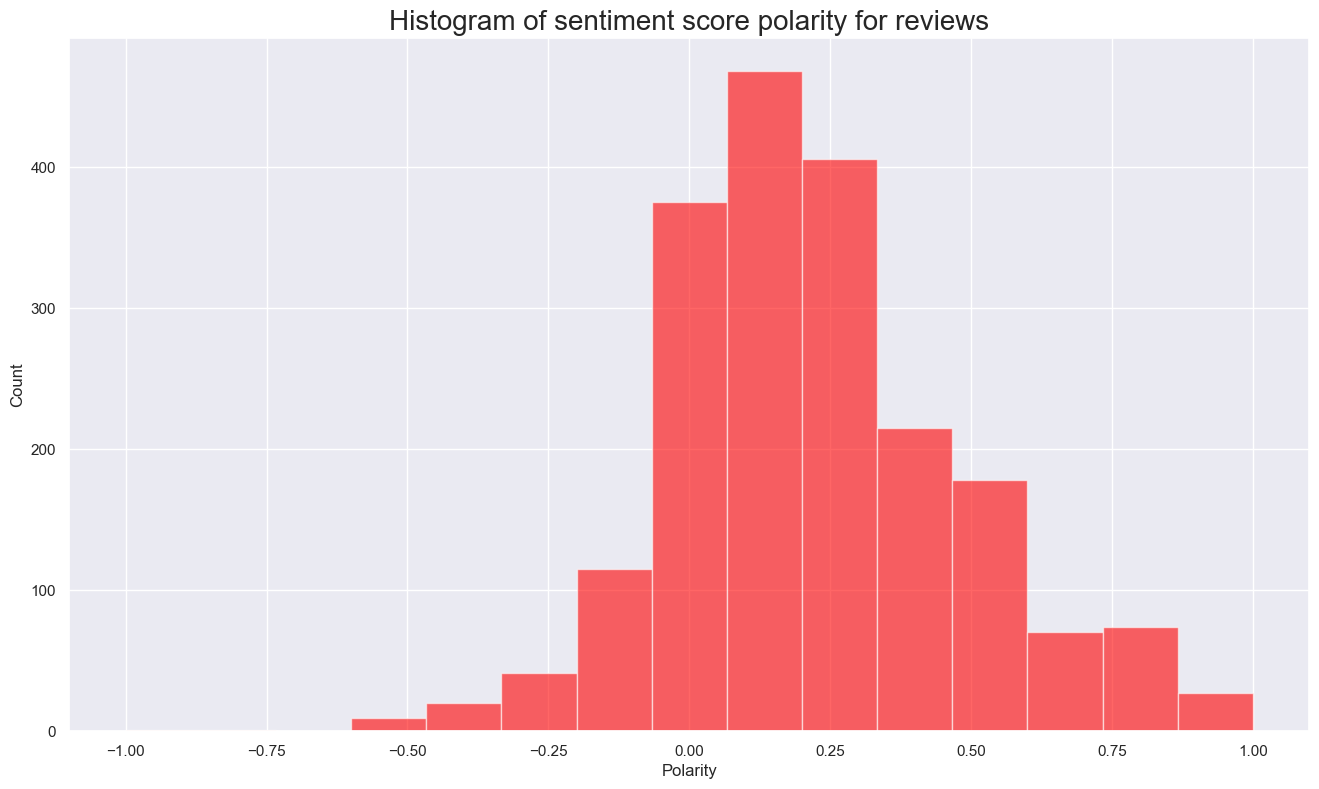

In [107]:
# Review: Create a histogram plot with bins = 15
# Histogram of polarity.
# Set the number of bins.
num_bins = 15

# Set the plot area.
plt.figure(figsize=(16,9))

# Define the bars.
n, bins, patches = plt.hist(turtle_NLP['Review Polarity'], num_bins, facecolor='red',
                            alpha=0.6)

# Set the labels.
plt.xlabel('Polarity', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Histogram of sentiment score polarity for reviews', fontsize=20)

plt.show()

A histogram showing the polarity of the reviews column. There is a reasonably positive sentiment towards the review column. Most of the observations on the review column has a polarity of score between 0 and 0.3 which is slightly positive. There are no fully negative reviews, but there are some fully positive reviews.

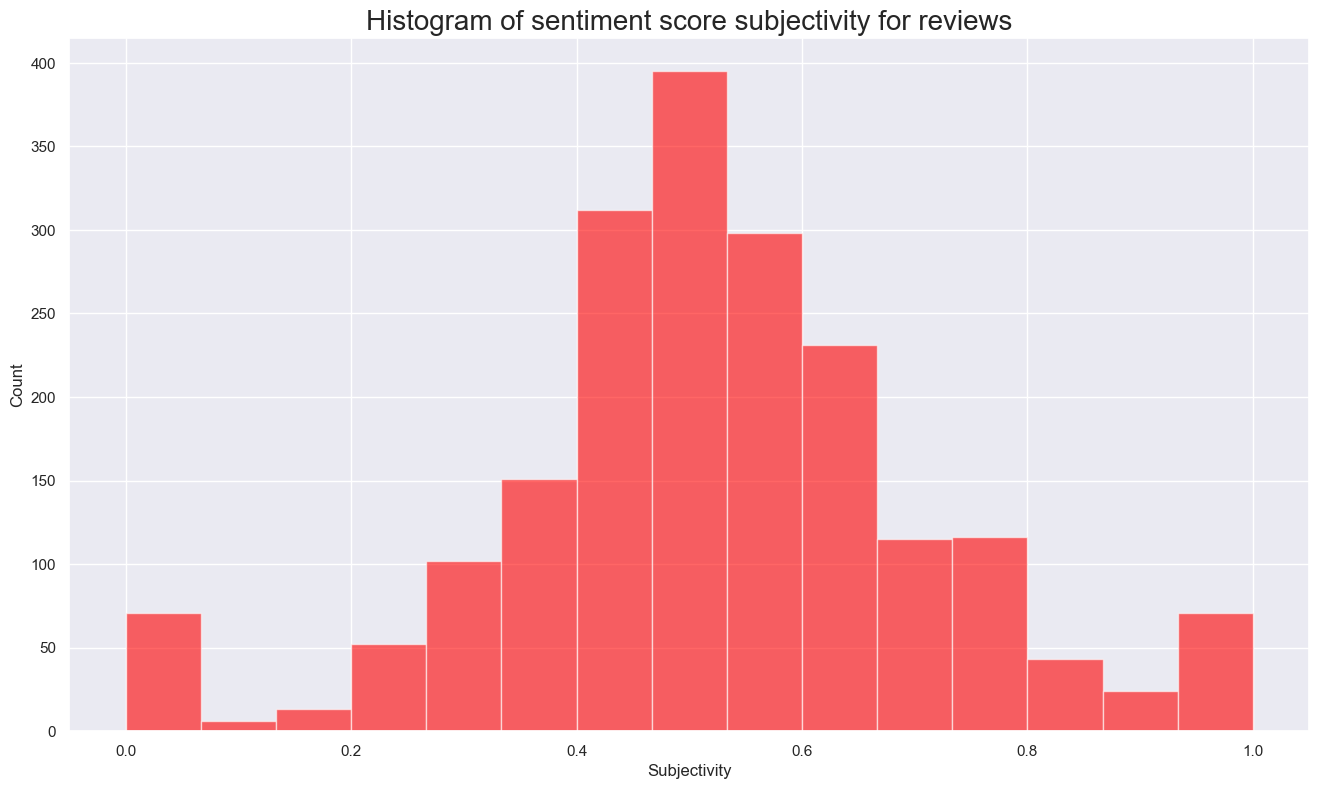

In [108]:
# Review: Create a histogram plot with bins = 15.
# Histogram of subjectivity score
# Set the number of bins.
num_bins = 15

# Set the plot area.
plt.figure(figsize=(16,9))

# Define the bars.
n, bins, patches = plt.hist(turtle_NLP['Review Subjectivity'], num_bins, facecolor='red',
                            alpha=0.6)

# Set the labels.
plt.xlabel('Subjectivity', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Histogram of sentiment score subjectivity for reviews', fontsize=20)

plt.show()

The subjectivity of the reviews column are tended towards the middle of the score, with some large extremes on both ends.

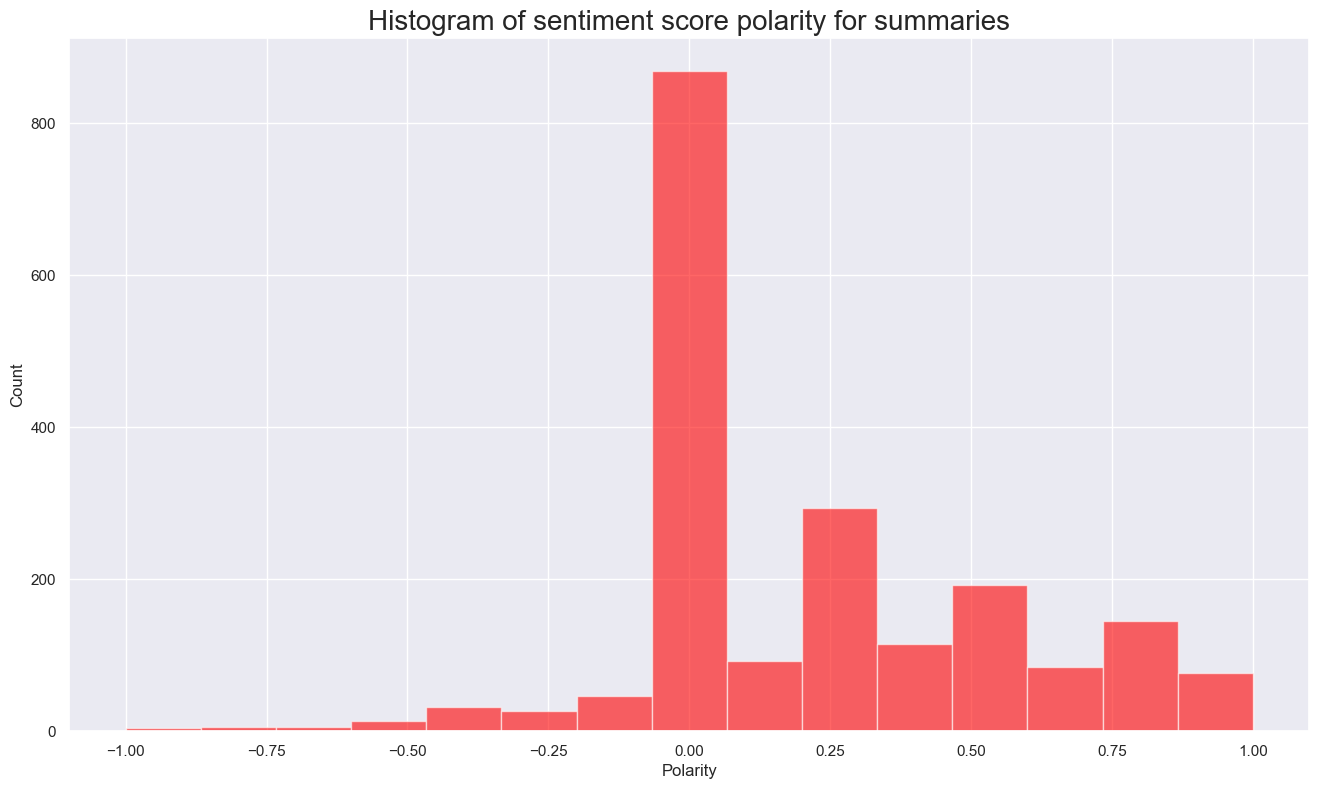

In [109]:
# Summary: Create a histogram plot with bins = 15.
# Histogram of polarity
# Set the number of bins.
num_bins = 15

# Set the plot area.
plt.figure(figsize=(16,9))

# Define the bars.
n, bins, patches = plt.hist(turtle_NLP['Summary Polarity'], num_bins, facecolor='red',
                            alpha=0.6)

# Set the labels.
plt.xlabel('Polarity', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Histogram of sentiment score polarity for summaries', fontsize=20)

plt.show()

The polarity of the summary score is significantly centred around neutral comments, with a slight lean towards the positive end. This might be incorrect because the two most common words are stars and 5, which is a positive response.

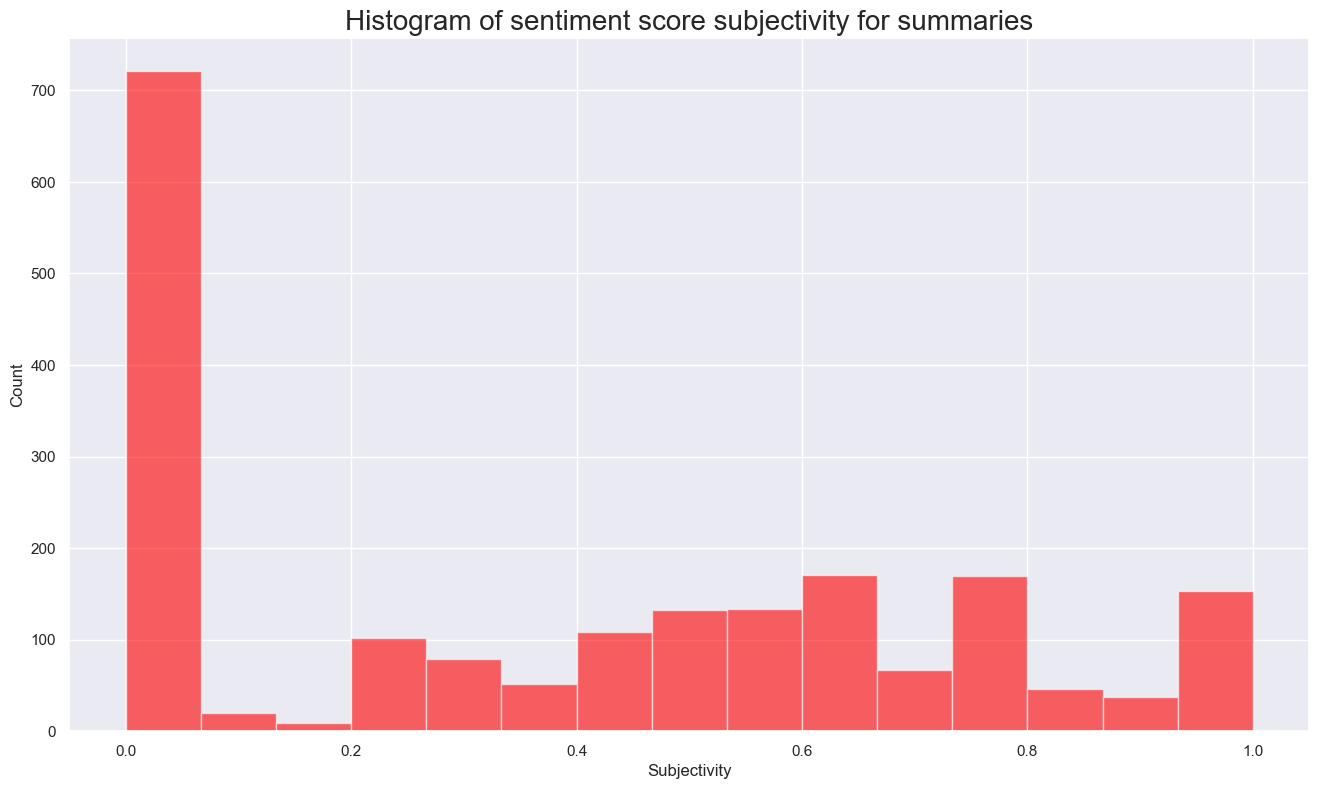

In [110]:
# Summary: Create a histogram plot with bins = 15.
# Histogram of subjectivity score
# Set the number of bins.
num_bins = 15

# Set the plot area.
plt.figure(figsize=(16,9))

# Define the bars.
n, bins, patches = plt.hist(turtle_NLP['Summary Subjectivity'], num_bins, facecolor='red',
                            alpha=0.6)

# Set the labels.
plt.xlabel('Subjectivity', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Histogram of sentiment score subjectivity for summaries', fontsize=20)

plt.show()

The subjectivity of the summary column is vastly objective as the 0.0 bin is the greatest. 

## 6. Identify top 20 positive and negative reviews and summaries respectively

In [111]:
# Top 20 negative reviews.
Neg_review = turtle_NLP.sort_values(by='Review Polarity', ascending=True)[['review', 'Review Polarity']]

# View output.
Neg_review.head(20)

,review,Review Polarity
208,booo unles you are patient know how to measure...,-1.000000
182,incomplete kit very disappointing,-0.780000
1804,im sorry i just find this product to be boring...,-0.583333
364,one of my staff will be using this game soon s...,-0.550000
230,i found the directions difficult,-0.500000
117,i bought this as a christmas gift for my grand...,-0.500000
301,difficult,-0.500000
1524,expensive for what you get,-0.500000
227,this was a gift for my daughter i found it dif...,-0.500000
290,instructions are complicated to follow,-0.500000


In [112]:
# Print each review in whole along with the score
for i, row in Neg_review.head(20).iterrows():
    print(f"""Polarity: {row['Review Polarity']:.6f}""")
    print(row['review'])
    print("-" * 80)

Polarity: -1.000000
booo unles you are patient know how to measure i didnt have the patience neither did my daughter boring unless you are a craft person which i am not
--------------------------------------------------------------------------------
Polarity: -0.780000
incomplete kit very disappointing
--------------------------------------------------------------------------------
Polarity: -0.583333
im sorry i just find this product to be boring and to be frank juvenile
--------------------------------------------------------------------------------
Polarity: -0.550000
one of my staff will be using this game soon so i dont know how well it works as yet but after looking at the cards i believe it will be helpful in getting a conversation started regarding anger and what to do to control it
--------------------------------------------------------------------------------
Polarity: -0.500000
i found the directions difficult
----------------------------------------------------------------

There are definitely some mistakes to the sentiment analysis. This shows the top 20 most negative reviews. Some of the reviews have been evaluated correctly, such as "im sorry i just find this product to be boring and to be frank juvenile" which is negative. There are also comments that can be discribed as positive but have been picked up as negative such as "addicted to this game". 

In [113]:
# Top 20 negative summaries.
Neg_summary = turtle_NLP.sort_values(by='Summary Polarity', ascending=True)[['summary', 'Summary Polarity']]

# View output.
Neg_summary.head(20)

,summary,Summary Polarity
21,the worst value ive ever seen,-1.000000
208,boring unless you are a craft person which i am,-1.000000
829,boring,-1.000000
1166,before this i hated running any rpg campaign d...,-0.900000
1,another worthless dungeon masters screen from ...,-0.800000
1620,disappointed,-0.750000
144,disappointed,-0.750000
793,disappointed,-0.750000
631,disappointed,-0.750000
363,promotes anger instead of teaching calming met...,-0.700000


In [114]:
# Print each summary in whole along with the polarity score.
for i, row in Neg_summary.head(20).iterrows():
    print(f"""Polarity: {row['Summary Polarity']:.6f}""")
    print(row['summary'])
    print("-" * 80)

Polarity: -1.000000
the worst value ive ever seen
--------------------------------------------------------------------------------
Polarity: -1.000000
boring unless you are a craft person which i am 
--------------------------------------------------------------------------------
Polarity: -1.000000
boring
--------------------------------------------------------------------------------
Polarity: -0.900000
before this i hated running any rpg campaign dealing with towns because it 
--------------------------------------------------------------------------------
Polarity: -0.800000
another worthless dungeon masters screen from galeforce9
--------------------------------------------------------------------------------
Polarity: -0.750000
disappointed
--------------------------------------------------------------------------------
Polarity: -0.750000
disappointed
--------------------------------------------------------------------------------
Polarity: -0.750000
disappointed
---------------

The polarity of the top 20 most negative summaries seems more appropriate when evaluating the NLP.

In [115]:
# Top 20 positive reviews.
Pos_review = turtle_NLP.sort_values(by='Review Polarity', ascending=False)[['review', 'Review Polarity']]

# View output.
Pos_review.head(20)

,review,Review Polarity
1168,best set buy 2 if you have the means,1.0
1401,one of the best board games i played in along ...,1.0
1967,perfect for tutoring my grandson in spelling,1.0
621,wonderful for my grandson to learn the resurre...,1.0
1720,it is the best thing to play with and also min...,1.0
609,delightful product,1.0
591,wonderful product,1.0
496,excellent activity for teaching selfmanagement...,1.0
194,awesome gift,1.0
1301,its awesome,1.0


In [116]:
# Print each review in whole along with polarity score.
for i, row in Pos_review.head(20).iterrows():
    print(f"""Polarity: {row['Review Polarity']:.6f}""")
    print(row['review'])
    print("-" * 80)

Polarity: 1.000000
best set buy 2 if you have the means
--------------------------------------------------------------------------------
Polarity: 1.000000
one of the best board games i played in along time
--------------------------------------------------------------------------------
Polarity: 1.000000
perfect for tutoring my grandson in spelling
--------------------------------------------------------------------------------
Polarity: 1.000000
wonderful for my grandson to learn the resurrection story
--------------------------------------------------------------------------------
Polarity: 1.000000
it is the best thing to play with and also mind blowing in some ways
--------------------------------------------------------------------------------
Polarity: 1.000000
delightful product
--------------------------------------------------------------------------------
Polarity: 1.000000
wonderful product
--------------------------------------------------------------------------------
Pol

The top 20 most positive all have a polarity score of 1. A cursory look, it seems correct.

In [117]:
# Top 20 positive summaries.
Pos_summary = turtle_NLP.sort_values(by='Summary Polarity', ascending=False)[['summary', 'Summary Polarity']]

# View output.
Pos_summary.head(20)

,summary,Summary Polarity
1417,wonderful and,1.0
1427,excellent expansion,1.0
580,the pigeon is the perfect addition to a school...,1.0
815,one of the best games ever,1.0
1656,a wonderful reading resource,1.0
475,excellent,1.0
1094,excellent product and everything i wanted it t...,1.0
1649,wonderful telling of a heart wrenching tale,1.0
1093,awesome,1.0
418,perfect,1.0


In [118]:
# Print each summary in full along with polarity score.
for i, row in Pos_summary.head(20).iterrows():
    print(f"""Polarity: {row['Summary Polarity']:.6}""")
    print(row['summary'])
    print("-" * 80)

Polarity: 1.0
wonderful and
--------------------------------------------------------------------------------
Polarity: 1.0
excellent expansion
--------------------------------------------------------------------------------
Polarity: 1.0
the pigeon is the perfect addition to a school library
--------------------------------------------------------------------------------
Polarity: 1.0
one of the best games ever
--------------------------------------------------------------------------------
Polarity: 1.0
a wonderful reading resource
--------------------------------------------------------------------------------
Polarity: 1.0
excellent
--------------------------------------------------------------------------------
Polarity: 1.0
excellent product and everything i wanted it to be
--------------------------------------------------------------------------------
Polarity: 1.0
wonderful telling of a heart wrenching tale
-----------------------------------------------------------------------

The top 20 most positive summaries are all scoring 1 on the polarity score. Some are not correct, such as "not the best quality".

## 7. Discuss: Insights and observations

***Your observations here...***

The products are being recieved very positively for the most part. There are a lot of positive comments, and fewer negative comments. However, some of the sentiment analysis has made mistakes and thus needs to be reviewed in greater detail.
The summaries and reviews are talking about products that Turtle sells, rather than comparing them to their competitors.

# Evaluate clusters

In [119]:
# Add polarity and subjectivity scores to turtle4.
# Generate polarity
turtle4['review_polarity'] = turtle4['review'].apply(generate_polarity)
turtle4['summary_polarity'] = turtle4['summary'].apply(generate_polarity)

# Generate subjectivity.
turtle4['review_subjectivity'] = turtle4['review'].apply(generate_subjectivity)
turtle4['summary_subjectivity'] = turtle4['summary'].apply(generate_subjectivity)

In [120]:
# View the DataFrame with the clusters.
turtle4.head()

,gender,age,income,spending_score,loyalty_points,education,product,review,summary,k-means_cluster,review_polarity,summary_polarity,review_subjectivity,summary_subjectivity
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...,3,-0.036111,0.15,0.486111,0.500000
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...,1,0.035952,-0.80,0.442976,0.900000
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless",3,0.116640,0.00,0.430435,0.733333
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars,1,0.628788,0.00,0.784848,0.000000
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap,3,-0.316667,0.00,0.316667,0.000000


In [121]:
# Evaluate turtle4.
turtle4.describe()

,age,income,spending_score,loyalty_points,product,k-means_cluster,review_polarity,summary_polarity,review_subjectivity,summary_subjectivity
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,39.495000,48.079060,50.000000,1578.032000,4320.521500,1.583000,0.225809,0.228522,0.519970,0.378116
std,13.573212,23.123984,26.094702,1283.239705,3148.938839,1.535347,0.275313,0.351692,0.192862,0.341731
min,17.000000,12.300000,1.000000,25.000000,107.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000
25%,29.000000,30.340000,32.000000,772.000000,1589.250000,0.000000,0.048596,0.000000,0.425000,0.000000
50%,38.000000,47.150000,50.000000,1276.000000,3624.000000,1.000000,0.183333,0.063750,0.512500,0.400000
75%,49.000000,63.960000,73.000000,1751.250000,6654.000000,3.000000,0.375000,0.488125,0.607197,0.633333
max,72.000000,112.340000,99.000000,6847.000000,11086.000000,4.000000,1.000000,1.000000,1.000000,1.000000


In [122]:
# Look at the unique values of the k-means_cluster column.
turtle4['k-means_cluster'].unique()

array([3, 1, 0, 4, 2], dtype=int32)

There are five different clusters, which is correct when we look at the k-means clustering process completed earlier.

In [123]:
# Split the DataFrame by each individual cluster.
turtle_k0 = turtle4[turtle4['k-means_cluster'] == 0]
turtle_k1 = turtle4[turtle4['k-means_cluster'] == 1]
turtle_k2 = turtle4[turtle4['k-means_cluster'] == 2]
turtle_k3 = turtle4[turtle4['k-means_cluster'] == 3]
turtle_k4 = turtle4[turtle4['k-means_cluster'] == 4]

In [124]:
# Evaluate turtle_k0.
turtle_k0.describe()

,age,income,spending_score,loyalty_points,product,k-means_cluster,review_polarity,summary_polarity,review_subjectivity,summary_subjectivity
count,774.000000,774.000000,774.000000,774.000000,774.000000,774.0,774.000000,774.000000,774.000000,774.000000
mean,42.129199,44.418786,49.529716,1420.382429,4273.248062,0.0,0.214129,0.227782,0.519291,0.397759
std,15.721916,7.088279,6.484414,322.530608,2992.163847,0.0,0.255910,0.351019,0.181101,0.340081
min,17.000000,31.980000,34.000000,504.000000,107.000000,0.0,-0.500000,-0.750000,0.000000,0.000000
25%,29.000000,38.540000,44.000000,1180.500000,2130.000000,0.0,0.050000,0.000000,0.433333,0.000000
50%,41.000000,44.280000,50.000000,1393.000000,3619.000000,0.0,0.170185,0.100000,0.520119,0.427778
75%,52.000000,50.020000,55.000000,1623.000000,6646.000000,0.0,0.350000,0.497500,0.600000,0.666667
max,72.000000,62.320000,61.000000,2332.000000,11086.000000,0.0,1.000000,1.000000,1.000000,1.000000


For cluster 0:
- Average age of 42. Minimum age of 17. Maximum age of 72.
- Average income of £44418.79. Minimum income of £31980. Maximum income of £62320.
- Average spending score of 49. Minimum spending score of 34. Maximum spending score of 61.
- Average loyalty points of 1420. Minimum loyalty points of 504. Maximum loyaylty points of 2332.
- Average review polarity of 0.21. Min review polarity of -0.5. Max reivew polarity of 1.
- Average summary polarity of 0.22. Min summary polarity of -0.75. Max summary polarity of 1.
- Average review subjectivity of 0.52. Min review subjectivity of 0. Max review subjectivity of 1.

In [125]:
# Check the most frequent gender, education and product.
print("Gender:", turtle_k0['gender'].value_counts())
print("Education:", turtle_k0['education'].value_counts())
print("Product:", turtle_k0['product'].value_counts())

Gender: gender
Female    446
Male      328
Name: count, dtype: int64
Education: education
graduate        347
postgraduate    175
PhD             165
diploma          76
Basic            11
Name: count, dtype: int64
Product: product
6233    9
9507    9
9529    9
6215    9
9530    9
       ..
1945    1
1970    1
195     1
107     1
4390    1
Name: count, Length: 179, dtype: int64


- Mostly female.
- mostly graduate.
- 179 different products

In [126]:
# Evaluate turtle_k1
turtle_k1.describe()

,age,income,spending_score,loyalty_points,product,k-means_cluster,review_polarity,summary_polarity,review_subjectivity,summary_subjectivity
count,269.000000,269.000000,269.000000,269.000000,269.000000,269.0,269.000000,269.000000,269.000000,269.000000
mean,31.602230,20.353680,79.416357,971.944238,2506.249071,1.0,0.233245,0.189963,0.505941,0.361839
std,10.731534,5.737253,10.395781,296.173785,2443.180202,0.0,0.293846,0.356453,0.202732,0.343374
min,17.000000,12.300000,61.000000,436.000000,107.000000,1.0,-0.583333,-1.000000,0.000000,0.000000
25%,24.000000,15.580000,73.000000,724.000000,811.000000,1.0,0.042857,0.000000,0.400000,0.000000
50%,29.000000,19.680000,77.000000,969.000000,1940.000000,1.0,0.187500,0.037500,0.510417,0.325000
75%,37.000000,24.600000,87.000000,1152.000000,3498.000000,1.0,0.400000,0.400000,0.600000,0.600000
max,71.000000,31.980000,99.000000,1851.000000,11084.000000,1.0,1.000000,1.000000,1.000000,1.000000


For cluster 1:
- Average age of 31. Min age of 17. Max age of 71.
- Average income of £20353.68. Min income of £12300. Max income of £31980.
- Average spending score of 79. Min spending score of 61. Max spending score of 99.
- Average loyalty points of 971. Min loyalty points of 436. Max loyalty points of 1851.
- Average review polarity of 0.23. Min review polarity of -0.58. Max review polarity of 1.
- Average summary polarity of 0.19. Min summary polarity of -1. Max summary polarity of 1.
- Average review subjectivity of 

In [127]:
# Check the most frequent gender, education and product.
print("Gender:", turtle_k1['gender'].value_counts())
print("Education:", turtle_k1['education'].value_counts())
print("Product:", turtle_k1['product'].value_counts())

Gender: gender
Female    151
Male      118
Name: count, dtype: int64
Education: education
graduate        134
PhD              71
postgraduate     53
diploma          10
Basic             1
Name: count, dtype: int64
Product: product
2162    6
2253    6
624     5
231     5
1940    5
       ..
7600    1
7533    1
7384    1
7381    1
453     1
Name: count, Length: 132, dtype: int64


- Mostly female, but a closer split compared to K0.
- Mostly graduate.
- 132 different products.

In [128]:
# Determine polarity of both columns for each each cluster.
# For turtle_k2
turtle_k2['Review Polarity'] = turtle_k2['review'].apply(generate_polarity)
turtle_k2['Summary Polarity'] = turtle_k2['summary'].apply(generate_polarity)

In [129]:
# Evaluate turtle_k2
turtle_k2.describe()

,age,income,spending_score,loyalty_points,product,k-means_cluster,review_polarity,summary_polarity,review_subjectivity,summary_subjectivity,Review Polarity,Summary Polarity
count,330.000000,330.000000,330.000000,330.000000,330.000000,330.0,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000
mean,40.666667,74.831212,17.424242,911.760606,5789.981818,2.0,0.237734,0.245510,0.541140,0.383192,0.237734,0.245510
std,11.357594,13.638540,9.515402,545.849379,3067.142734,0.0,0.293911,0.355989,0.199242,0.347381,0.293911,0.355989
min,17.000000,57.400000,1.000000,40.000000,123.000000,2.0,-0.975000,-0.900000,0.000000,0.000000,-0.975000,-0.900000
25%,35.250000,63.960000,10.000000,499.000000,3269.500000,2.0,0.046823,0.000000,0.433333,0.000000,0.046823,0.000000
50%,39.000000,71.340000,16.000000,874.000000,5740.000000,2.0,0.182188,0.102083,0.506667,0.436667,0.182188,0.102083
75%,46.000000,82.820000,23.750000,1328.000000,7600.000000,2.0,0.413125,0.500000,0.634709,0.650000,0.413125,0.500000
max,72.000000,112.340000,39.000000,2325.000000,11086.000000,2.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


For cluster 2
- Average age of 40. Min age of 17. Max age of 72.
- Average income of £74831.21. Min income of £57400. Max income of £112340.
- Average spending score of 17. Min spending score of 1. Max spending score of 39.
- Average loyalty points of 911. Min loyalty points of 40. Max loyalty points of 2325.
- Average Review polarity of 0.23. Min review polarity of -0.97. Max review polarity of 1.
- Average summary polarity of 0.24. Min summary polarity of -0.9. Max summary polarity of 1.
- Average review subjectivity of 0.54. Min review subjectivity of 0. Max review subjectivity of 1.
- Average summary subjectivity of 0.38. Min summary subjectivity of 0. Max summary subjectivity of 1.

In [130]:
# Check the most frequent gender, education and product.
print("Gender:", turtle_k2['gender'].value_counts())
print("Education:", turtle_k2['education'].value_counts())
print("Product:", turtle_k2['product'].value_counts())

Gender: gender
Male      173
Female    157
Name: count, dtype: int64
Education: education
graduate        116
PhD              98
postgraduate     72
diploma          26
Basic            18
Name: count, dtype: int64
Product: product
6507    6
4390    6
4405    6
3112    6
8933    6
       ..
1175    1
486     1
1506    1
1497    1
123     1
Name: count, Length: 114, dtype: int64


- Mostly male.
- Mostly graduate, but some Phd.
- 114 different products.

In [131]:
# Evaluate turtle_k3
turtle_k3.describe()

,age,income,spending_score,loyalty_points,product,k-means_cluster,review_polarity,summary_polarity,review_subjectivity,summary_subjectivity
count,271.000000,271.000000,271.000000,271.000000,271.000000,271.0,271.000000,271.000000,271.000000,271.000000
mean,43.505535,20.424354,19.763838,275.059041,2596.749077,3.0,0.213281,0.247810,0.506086,0.360600
std,13.961553,5.719723,12.666796,198.236064,2540.905194,0.0,0.291009,0.364476,0.189003,0.342573
min,17.000000,12.300000,3.000000,25.000000,107.000000,3.0,-1.000000,-1.000000,0.000000,0.000000
25%,37.000000,15.580000,6.000000,75.000000,813.000000,3.0,0.042804,0.000000,0.417535,0.000000
50%,41.000000,19.680000,15.000000,236.000000,1940.000000,3.0,0.192647,0.050000,0.507778,0.350000
75%,52.000000,24.600000,32.000000,417.000000,3637.000000,3.0,0.354428,0.500000,0.601131,0.600000
max,72.000000,31.980000,40.000000,726.000000,11086.000000,3.0,1.000000,1.000000,1.000000,1.000000


For cluster 3:
- Average age of 43. Min age of 17. Max age of 72.
- Average income of £20424.44. Min income of £12300. Max income of £31980.
- Average spending score of 20. Min spending score of 3. Max spending score of 40.
- Average loyalty points of 275. Min loyalty points of 25. Max loyalty points of 726.
- Average review polarity of 0.21. Min review polarity of -1. Max review polarity of 1.
- Average summary polarity of 0.36. Min summary polarity of -1. Max summary polarity of 1.
- Average review subjectivity of 0.51. Min review subjectivity of 0. Max review subjectivity of 1.
- Average summary subjectivity of 0.36. Min summary subjectivity of 0. Max summary subjectivity of 1.

In [132]:
# Check the most frequent gender, education and product.
print("Gender:", turtle_k3['gender'].value_counts())
print("Education:", turtle_k3['education'].value_counts())
print("Product:", turtle_k3['product'].value_counts())

Gender: gender
Female    170
Male      101
Name: count, dtype: int64
Education: education
graduate        113
PhD              65
diploma          51
postgraduate     39
Basic             3
Name: count, dtype: int64
Product: product
2139    6
1031    6
2173    6
2261    6
760     5
       ..
4692    1
4619    1
7573    1
7532    1
4065    1
Name: count, Length: 131, dtype: int64


- Mostly female.
- Mostly graduate.
- 131 different products.

In [133]:
# Evaluate turtle_k4.
turtle_k4.describe()

,age,income,spending_score,loyalty_points,product,k-means_cluster,review_polarity,summary_polarity,review_subjectivity,summary_subjectivity
count,356.000000,356.000000,356.000000,356.000000,356.000000,356.0,356.000000,356.000000,356.000000,356.000000
mean,35.592697,73.240281,82.008427,3988.238764,5744.255618,4.0,0.244068,0.228836,0.522993,0.356339
std,7.299612,13.557856,9.342765,898.409322,3065.704798,0.0,0.271359,0.334817,0.205723,0.337449
min,18.000000,56.580000,63.000000,2289.000000,107.000000,4.0,-0.625000,-0.750000,0.000000,0.000000
25%,32.000000,63.140000,74.000000,3218.000000,3158.000000,4.0,0.056176,0.000000,0.433333,0.000000
50%,34.000000,71.340000,83.000000,3866.000000,5726.000000,4.0,0.200018,0.050833,0.508333,0.340000
75%,38.000000,81.180000,90.000000,4635.000000,7600.000000,4.0,0.393404,0.500000,0.613906,0.600000
max,72.000000,112.340000,97.000000,6847.000000,11086.000000,4.0,1.000000,1.000000,1.000000,1.000000


For cluster 4:
- Average age of 36. Min age of 18. Max age of 72.
- Average income of £73240.28. Min income of £56580. Max income of £112340.
- Average spending score of 82. Min spending score of 63. Max spending score of 97.
- Average loyalty points of 3988. Min loyalty points of 2289. Max loyalty points of 6847.
- Average review polarity of 0.24. Min review polarity of -0.63. Max review polarity of 1.
- Average summary polarity of 0.23. Min summary polarity of -0.75. Max summary polarity of 1.
- Average review subjectivity of 0.52. Min review subjectivity of 0. Max review subjectivity of 1.
- Average summary polarity of 0.36. Min summary subjectivity of 0. Max summary subjectivity of 1.

In [134]:
# Check the most frequent gender, education and product.
print("Gender:", turtle_k4['gender'].value_counts())
print("Education:", turtle_k4['education'].value_counts())
print("Product:", turtle_k4['product'].value_counts())

Gender: gender
Female    196
Male      160
Name: count, dtype: int64
Education: education
graduate        190
postgraduate     61
PhD              61
diploma          27
Basic            17
Name: count, dtype: int64
Product: product
4415    6
4399    6
8923    6
8962    6
9080    6
       ..
1473    1
1459    1
1175    1
1506    1
466     1
Name: count, Length: 116, dtype: int64


- More females.
- Most graduate
- 116 different products.